# Projet d'Analyse de données



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from skimpy import skim
import seaborn as sns 
import prince
from statsmodels.graphics.mosaicplot import mosaic
from pandas.plotting import scatter_matrix
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

%matplotlib inline

# Introduction


## Prise en charge et présentation du jeu de données 

In [2]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard entre 15 et 30 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard entre 30 et 60 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard > 15min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard > 30min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))


Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


In [3]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst_full.ods',engine='odf')
data = data.rename(columns=short_names)

In [4]:
data['moy_retard_train_deja_retard'] = np.where(
    data['dep_late_trains'] > 0, 
    (data['dep_avg_all'] * data['planned_trains']) / data['dep_late_trains'], 
    0  # Valeur par défaut si aucun train n'est en retard
)

In [5]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
]
data = data.drop(columns=cols_to_drop)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')

In [6]:
proportion_retard = (data['arr_late_trains']+data['cancelled_trains']) / data['planned_trains']

bins = [-0.01, 0.05, 0.15, 0.40, 1.0]
labels = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']

data['retard'] = pd.cut(proportion_retard, bins=bins, labels=labels)

print(data['retard'].value_counts())

retard
Rarement         5461
Régulièrement    5443
Souvent           553
Jamais            304
Name: count, dtype: int64


# Analyse des retards au cours des années

In [7]:
# Paramètres d'affichage communs à toute la partie
# ──────────────────────────────────────────────────────────────────────────────
# Palette de 8 couleurs par année (2018→2025)
COULEURS_ANNEES = [
    '#E6194B', # 2018 : Rouge
    '#3CB44B', # 2019 : Vert
    '#FFE119', # 2020 : Jaune
    '#4363D8', # 2021 : Bleu
    '#F58231', # 2022 : Orange
    '#911EB4', # 2023 : Violet
    '#42D4F4', # 2024 : Cyan
    '#F032E6'  # 2025 : Magenta
]

# Noms courts et complets des mois
NOMS_MOIS = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Jun',
             7: 'Juil', 8: 'Aoû', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Déc'}
NOMS_MOIS_COMPLETS = {
    1: 'Janvier', 2: 'Février', 3: 'Mars', 4: 'Avril', 5: 'Mai', 6: 'Juin',
    7: 'Juillet', 8: 'Août', 9: 'Septembre', 10: 'Octobre', 11: 'Novembre', 12: 'Décembre'
}

# Style commun des flèches AFC/FAMD (variables)
AFC_ARROW = dict(color='darkred', alpha=0.6, width=0.008, head_width=0.08, length_includes_head=True)
AFC_LABEL = dict(color='darkred', fontsize=14, fontweight='bold', ha='center')
AFC_LABEL_BBOX = dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='none')

# Style commun des axes AFC/FAMD
AFC_HLINE = dict(color='black', linewidth=1.5, zorder=1)
AFC_GRID  = dict(linestyle='--', alpha=0.4, zorder=0)

# Taille de figure standard pour les graphiques AFC plein écran
FIG_SIZE_AFC   = (16, 12)
FIG_SIZE_SMALL = (12, 10)
FIG_SIZE_MOIS  = (14, 10)

### A. AFC globale mois-années

#### A.1. AFC globale

Aperçu de la matrice de contingence :
retard   Jamais  Rarement  Régulièrement  Souvent
periode                                          
2018-01       1        61             68        0
2018-02       3        26             94        7
2018-03       2        57             70        1
2018-04       2         2             38       88
2018-05       1         3             68       58
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.380        68.64%                     68.64%
1              0.140        25.26%                     93.90%


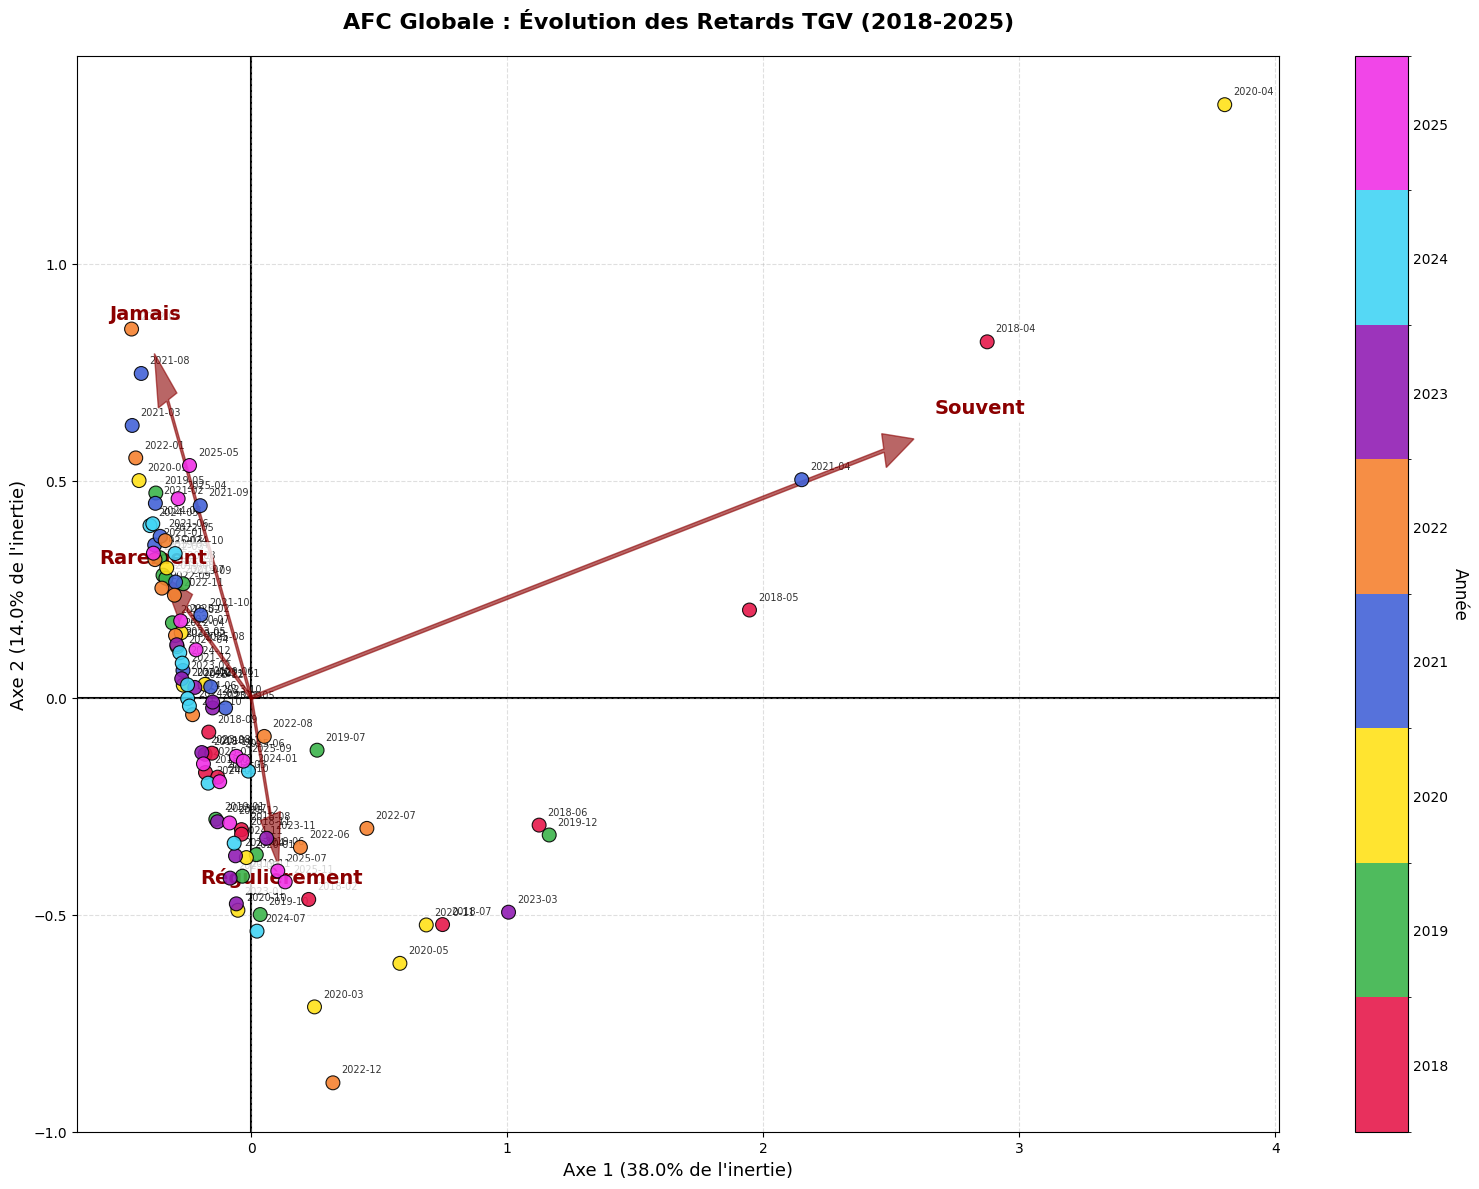

In [8]:
# A.1. AFC globale — Préparation des données et lancement de l'AFC

# Créer la période
data['periode'] = data['date'].astype(str)

# Matrice de contingence
matrice_contingence = data.groupby(['periode', 'retard']).size().unstack(fill_value=0)

# Vérification : s'assurer qu'il n'y a pas de lignes vides
if matrice_contingence.empty:
    raise ValueError("La matrice de contingence est vide. Vérifiez vos colonnes 'date' et 'retard'.")

print("Aperçu de la matrice de contingence :")
print(matrice_contingence.head())

# 2. LANCEMENT DE L'AFC
afc = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc = afc.fit(matrice_contingence)

# 3. PRÉPARATION DES COORDONNÉES
coords_individus = afc.row_coordinates(matrice_contingence)
coords_individus.columns = ['Axe 1', 'Axe 2']

# Get inertia values
print(afc.eigenvalues_summary)
inertie_1 = afc.eigenvalues_[0]
inertie_2 = afc.eigenvalues_[1]
# Get variable coordinates
coords_variables = afc.column_coordinates(matrice_contingence)
coords_variables.columns = ['Axe 1', 'Axe 2']

# On convertit l'index en Series pour pouvoir utiliser les méthodes de chaîne
index_series = coords_individus.index.to_series()

# Extraction de l'année depuis l'index (ex: "2020-04" -> "2020")
index_series = coords_individus.index.to_series()
coords_individus['annee_str'] = index_series.str[:4]
coords_individus['annee_num'] = coords_individus['annee_str'].astype(int)

# Extract unique years
annees_uniques = sorted(coords_individus['annee_num'].unique())

# Création de la colormap à partir de la palette partagée
cmap_personnalisee = mcolors.LinearSegmentedColormap.from_list('ma_cmap', COULEURS_ANNEES, N=8)

# Création des bornes pour que chaque année ait sa propre case centrée
# Les bornes sont placées "entre" les années : [2017.5, 2018.5, 2019.5, ..., 2025.5]
bornes = [x - 0.5 for x in annees_uniques] + [annees_uniques[-1] + 0.5]
norm = mcolors.BoundaryNorm(bornes, cmap_personnalisee.N)


# --- 4. VISUALISATION AVEC BARRE DE COULEUR "EN CASES" ---
plt.figure(figsize=FIG_SIZE_AFC)

# Tracé des variables (Flèches)
for i, txt in enumerate(coords_variables.index):
    x, y = coords_variables['Axe 1'].iloc[i], coords_variables['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, **AFC_ARROW, zorder=5)
    plt.text(x*1.1, y*1.1, txt, **AFC_LABEL, bbox=AFC_LABEL_BBOX, zorder=6)

# Tracé des individus avec la nouvelle normalisation
scatter = plt.scatter(
    coords_individus['Axe 1'], 
    coords_individus['Axe 2'], 
    c=coords_individus['annee_num'], 
    cmap=cmap_personnalisee, 
    norm=norm,  # Application de la normalisation discrète
    s=100, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=0.8,
    zorder=10
)

# Annotation des points
for i, txt in enumerate(coords_individus.index):
    x_val = coords_individus['Axe 1'].iloc[i]
    y_val = coords_individus['Axe 2'].iloc[i]
    plt.annotate(txt, (x_val, y_val), 
                 xytext=(6, 6), textcoords='offset points', 
                 fontsize=7, alpha=0.8, ha='left', va='bottom')

# Configuration de la barre de couleur
cbar = plt.colorbar(scatter, ticks=annees_uniques) # Les ticks sont exactement les années
cbar.set_label('Année', rotation=270, labelpad=15, fontsize=12)
cbar.set_ticklabels([str(int(a)) for a in annees_uniques])

# Ajustement des ticks pour qu'ils soient au centre des cases
cbar.ax.tick_params(length=0) # Optionnel : retirer les traits de ticks pour un look plus "case"

plt.title("AFC Globale : Évolution des Retards TGV (2018-2025)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2:.1%} de l'inertie)", fontsize=13)

plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **AFC_GRID)

plt.tight_layout()
plt.show()

Ce premier graphique d'une AFC globale sur les données en mois-années nous permet déjà d'identifier une répartition précise des individus dans le plan de l'AFC. On remarque une forme d'angle partant du haut gauche jusqu'au haut droit sur lequel les mois sont organisés selon un retard croissant. Les projections des variables nous le montre clairement : jamais en haut / rarement en dessous / régulièrement en bas / souvent en haut à droite.
On a une forte agglomération des points dans la partie gauche de l'angle ave une représentation variée des années. On ne distingue pas vraiment de tendances qui se dégagent dans cette partie. Nous pourrons voir par la suite des graphiques mettant en relief chaque année.

L'année 2020 se distingue particulièrement avec plusieurs individus dans la partie en bas et à droite. On remarque aussi des mois "outliers" forts : 2018-04 / 2018-05 / 2018-06 / 2020-04 / 2021-04.

Nous avons retrouvé les 2 évènements qui peuvent expliquer ces positons : le premier est la grande grève des cheminots du printemps 2018 et le deuxième sont les 3 confinements dus au Covid-19.

Voyons tout de suite un graphique avec les mois de confinements mis en valeur dans le graphe.

#### A.2. Mise en évidence des périodes de confinement

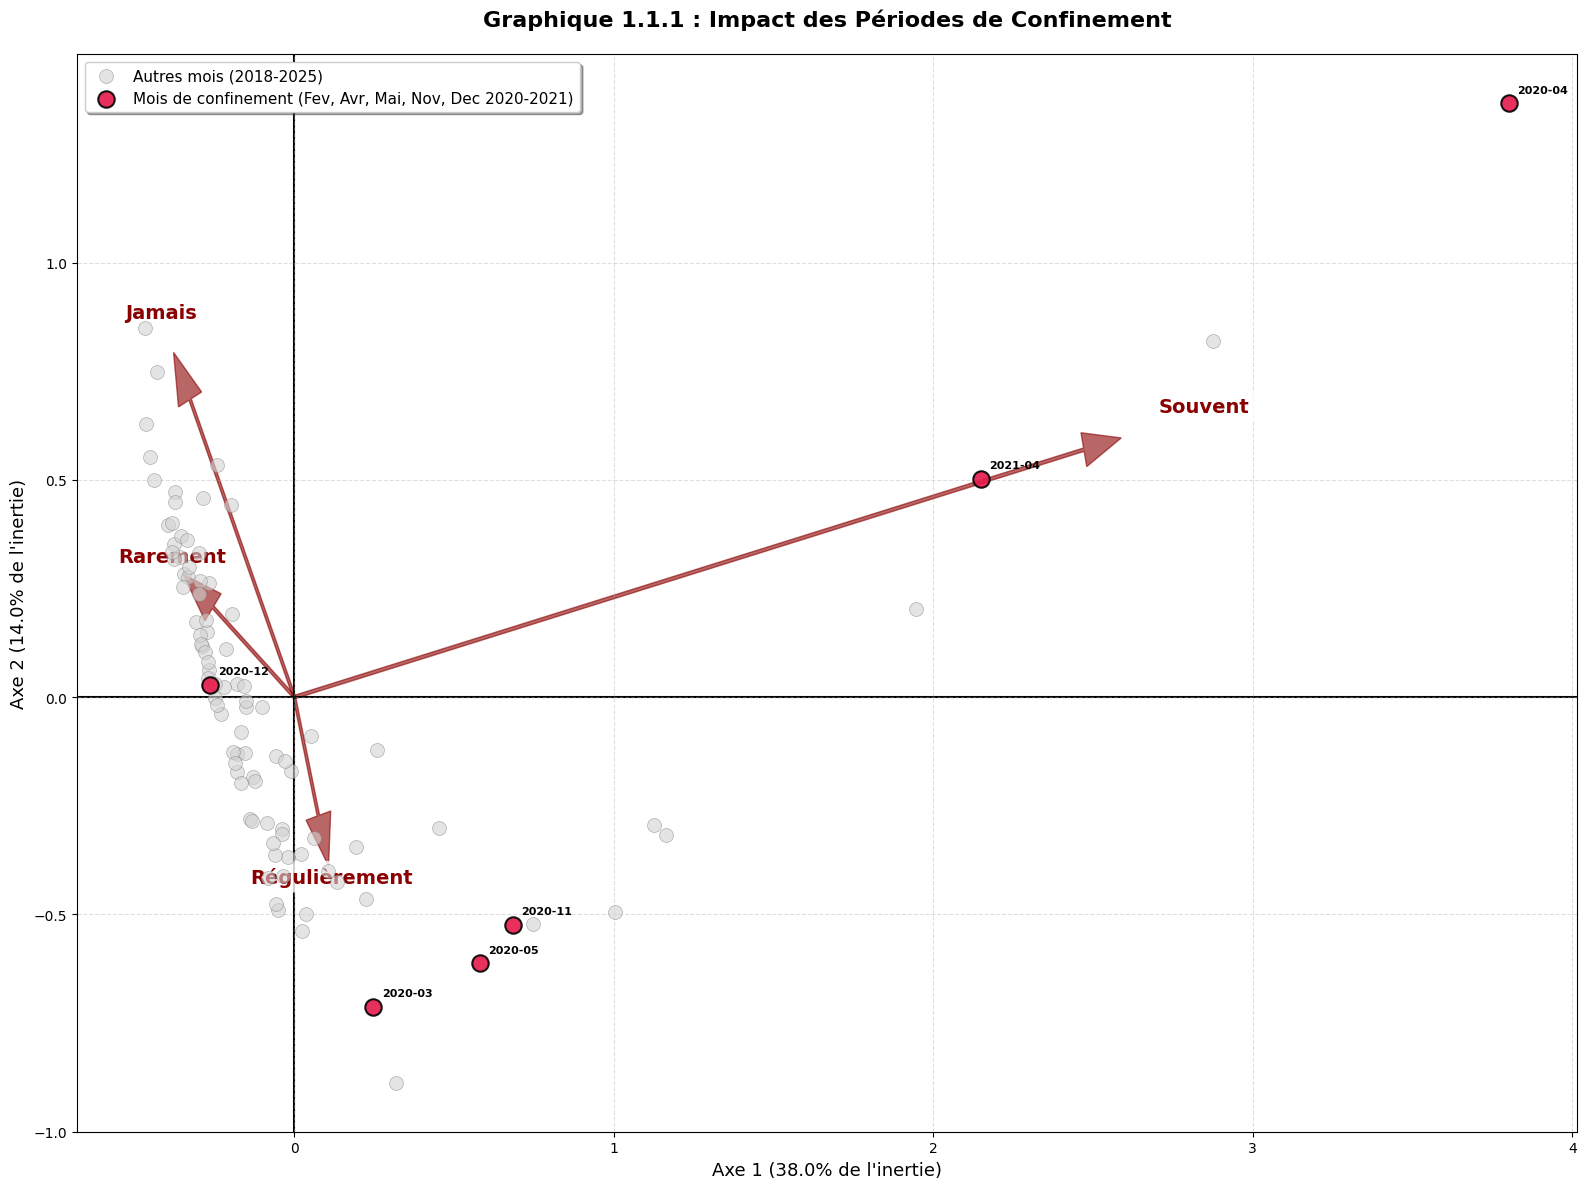

In [9]:
# A.2. Visualisation ciblée : Périodes de confinement

# A. Préparation des données temporelles
coords_individus['mois_num'] = coords_individus.index.str.split('-').str[1].astype(int)

# Définition stricte des périodes de confinement
# Mars(3), Avril(4), Mai(5), Nov(11), Dec(12) en 2020 ET Avril(4) en 2021
liste_periodes = [
    (2020, 3), (2020, 4), (2020, 5), (2020, 11), (2020, 12),
    (2021, 4)
]

# Création d'une condition combinée pour identifier ces périodes spécifiques
# On crée un tuple (année, mois) pour chaque ligne et on vérifie s'il est dans la liste
coords_individus['tuple_date'] = list(zip(coords_individus['annee_num'], coords_individus['mois_num']))
mask_confinement = coords_individus['tuple_date'].isin(liste_periodes)

# Séparation des données pour le tracé
df_confinement = coords_individus[mask_confinement]
df_autres = coords_individus[~mask_confinement]

# B. Visualisation
plt.figure(figsize=FIG_SIZE_AFC)

# Tracé des variables (Flèches)
for i, txt in enumerate(coords_variables.index):
    x, y = coords_variables['Axe 1'].iloc[i], coords_variables['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, **AFC_ARROW, zorder=1)
    plt.text(x*1.1, y*1.1, txt, **AFC_LABEL, bbox=AFC_LABEL_BBOX, zorder=2)

# Tracé des individus "Autres" (Gris)
plt.scatter(
    df_autres['Axe 1'], 
    df_autres['Axe 2'], 
    c='lightgray', 
    s=100, 
    alpha=0.6, 
    edgecolors='gray', 
    linewidth=0.5,
    label='Autres mois (2018-2025)',
    zorder=10
)

# Tracé des individus "Confinement" (Rouge)
plt.scatter(
    df_confinement['Axe 1'], 
    df_confinement['Axe 2'], 
    c='#E6194B', 
    s=140, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=1.5,
    label='Mois de confinement (Fev, Avr, Mai, Nov, Dec 2020-2021)',
    zorder=11
)

# Annotation spécifique aux points de confinement
for i, txt in enumerate(df_confinement.index):
    x_val = df_confinement['Axe 1'].iloc[i]
    y_val = df_confinement['Axe 2'].iloc[i]
    plt.annotate(txt, (x_val, y_val), 
                 xytext=(6, 6), textcoords='offset points', 
                 fontsize=8, fontweight='bold', color='black',
                 ha='left', va='bottom', zorder=12)

# Légende et mise en forme
plt.legend(loc='upper left', frameon=True, fancybox=True, shadow=True, fontsize=11)
plt.title("Graphique 1.1.1 : Impact des Périodes de Confinement", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2:.1%} de l'inertie)", fontsize=13)

plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **AFC_GRID)

plt.tight_layout()
plt.show()

On peut identifier une tendance supplémentaire des mois de confinements pour les retards et annulations de train, ce qui semble plutôt cohérent. Nous referons des analyses en sortant ces mois-ci ainsi que les mois du printemps 2018. Nous verrons à quel point les axes des variables sont influencés par ces outliers.

On garde la même ACP et on colorise maintenant les individus avec un gradient de couleur qui croit dans le temps pour répondre à la question : peut-on voir une évolution de l'emplacement des points dans le temps et donc noter des tendances sur l'évolution des moyennes des retards ?

#### A.3. Gradient temporel continu

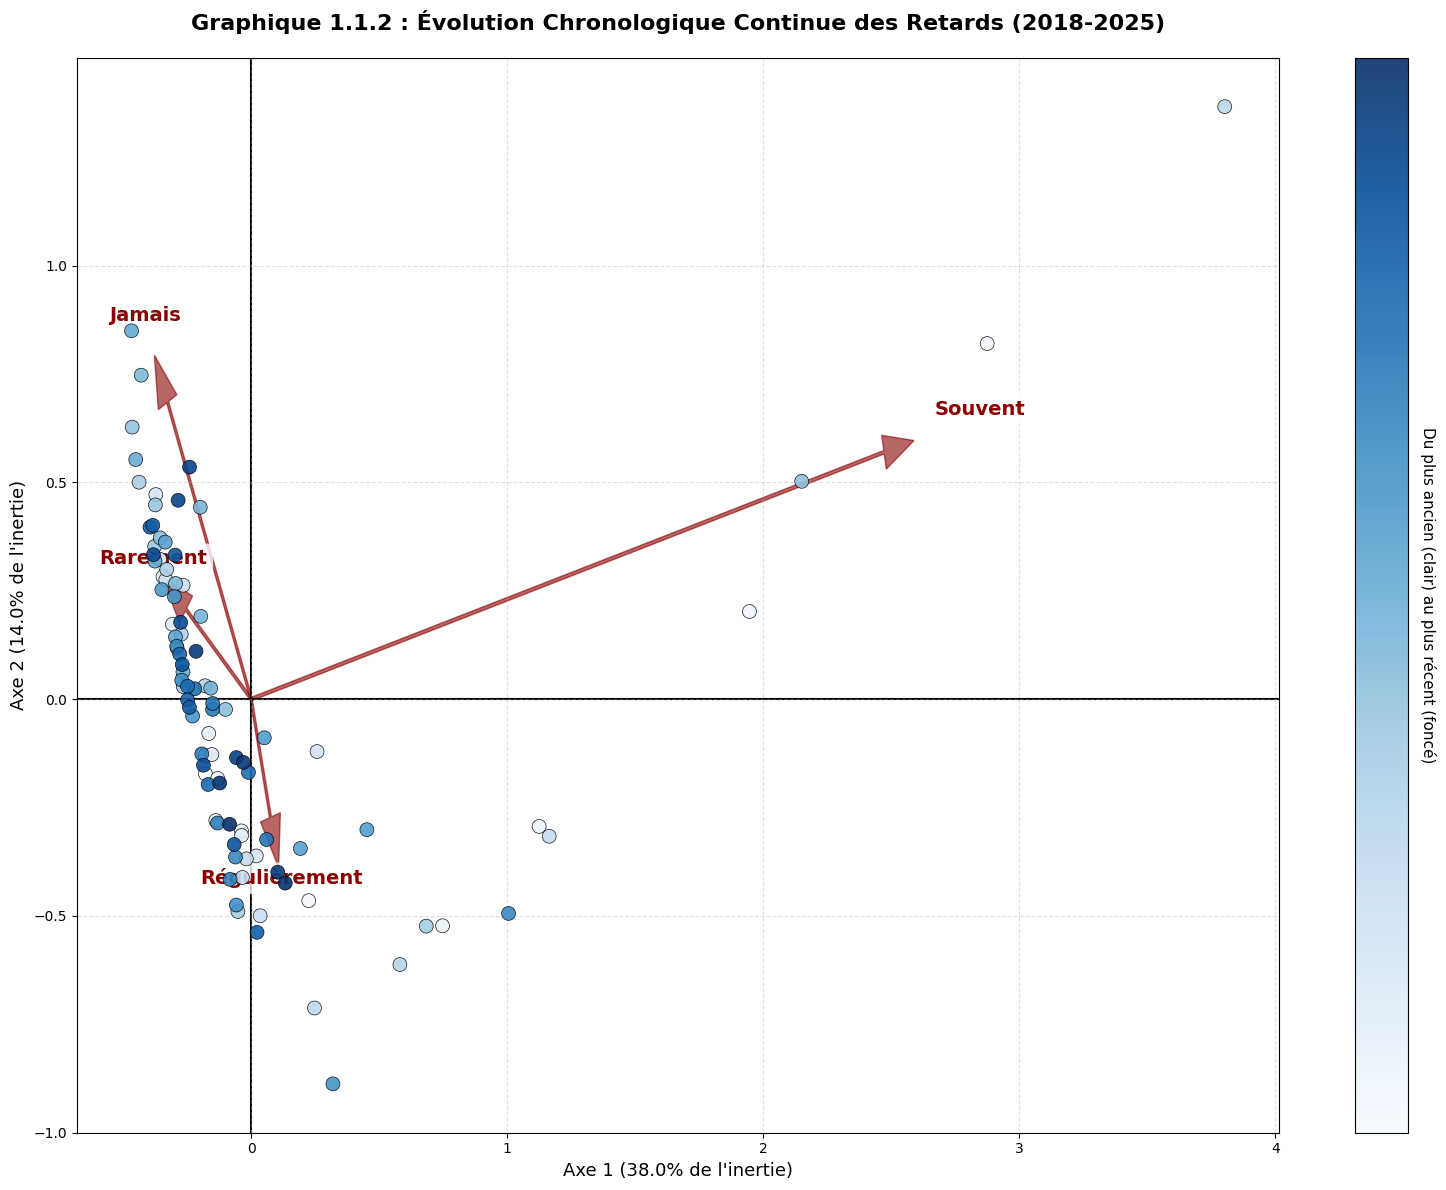

In [10]:
# A.3. Gradient temporel continu (Time Gradient)

# A. Création d'un index temporel continu
# On convertit l'index (ex: "2018-01") en objet datetime pour le trier chronologiquement
coords_individus['date_obj'] = pd.to_datetime(coords_individus.index)
coords_individus = coords_individus.sort_values('date_obj')

# On crée un index numérique continu (0 à N) représentant l'écoulement du temps
# 0 = Janvier 2018, 1 = Février 2018, ..., 95 = Décembre 2025
coords_individus['time_index'] = np.arange(len(coords_individus))

# B. Visualisation
plt.figure(figsize=FIG_SIZE_AFC)

# Tracé des variables (Flèches)
for i, txt in enumerate(coords_variables.index):
    x, y = coords_variables['Axe 1'].iloc[i], coords_variables['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, **AFC_ARROW, zorder=1)
    plt.text(x*1.1, y*1.1, txt, **AFC_LABEL, bbox=AFC_LABEL_BBOX, zorder=2)

# Tracé des individus avec dégradé de couleur
# On utilise 'time_index' comme valeur de couleur pour créer le gradient
scatter = plt.scatter(
    coords_individus['Axe 1'], 
    coords_individus['Axe 2'], 
    c=coords_individus['time_index'], 
    cmap='Blues',  # Palette monotone : du bleu clair au bleu foncé
    s=100, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=0.5,
    zorder=10
)

# Configuration de la barre de couleur (Gradient continu)
cbar = plt.colorbar(scatter, label='Écoulement du temps (Chronologie)')
cbar.set_ticks([]) # On retire les ticks numériques pour garder un aspect pur "dégradé"
cbar.ax.set_ylabel('Du plus ancien (clair) au plus récent (foncé)', rotation=270, labelpad=20, fontsize=11)

plt.title("Graphique 1.1.2 : Évolution Chronologique Continue des Retards (2018-2025)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2:.1%} de l'inertie)", fontsize=13)

plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **AFC_GRID)

plt.tight_layout()
plt.show()

# Nettoyage des colonnes temporaires
coords_individus.drop(columns=['date_obj', 'time_index'], inplace=True)

Ce graphique est le premier à montrer une tendance que nous pourrons observer dans d'autres plot après : les retards des trains tendent à se stabiliser. En effet, on voit que les points foncés sont plutôt concentrés dans une zone précise et que donc la variance des retards diminue. Nous pourrons observer ces mêmes conclusions avec d'autres projections. 



Maintenant que nous avons une vision globale de la répartition des individus en tant que mois-années nous nous intéressons aux années globales. Nous allons pouvoir comparer 2 graphiques : une nouvelle AFC sur les données agrégées de chaque année pour voir les tendances lourdes pouvant se dégager et les graphiques mettant en relief les mois de chaque année dans la première AFC.

### B. Analyse sur les années : Grille comparative et AFC agrégée

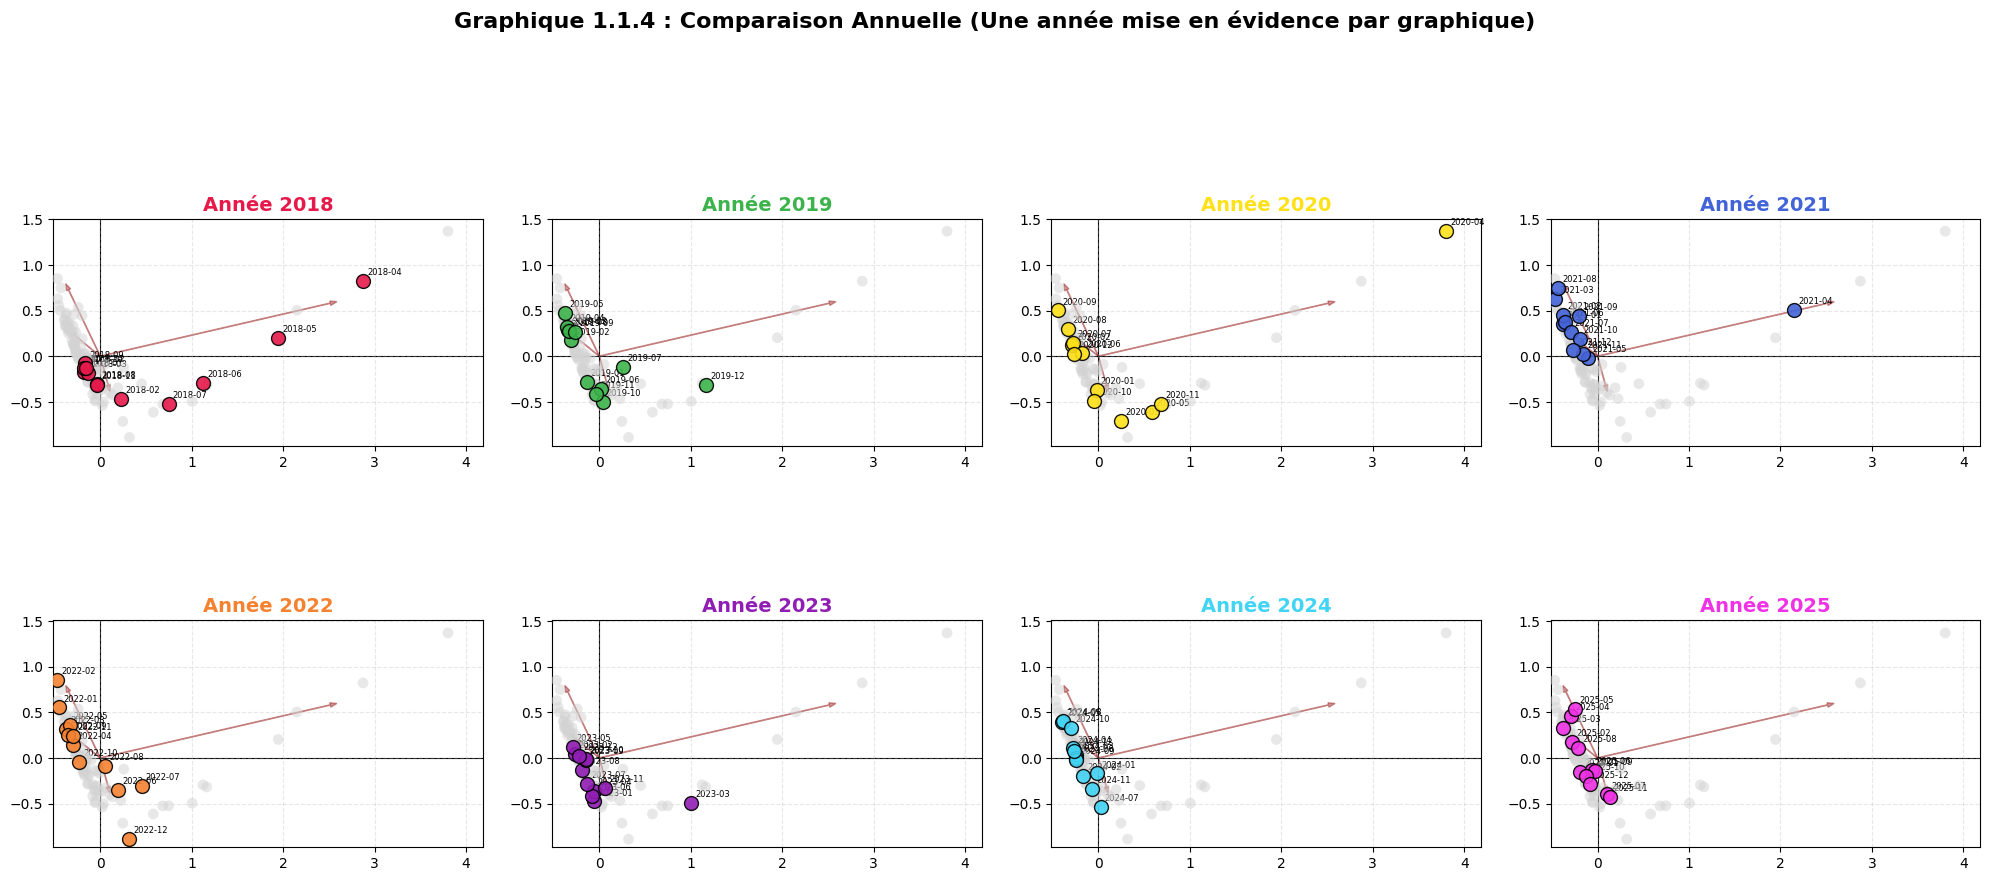

In [11]:
# B.1. Grille comparative : Une année en couleur par sous-graphique

# A. Préparation des données
# Réutilisation de coords_individus et coords_variables de la cellule 1.1
if 'annee_str' not in coords_individus.columns:
    coords_individus['annee_str'] = coords_individus.index.str[:4]
if 'annee_num' not in coords_individus.columns:
    coords_individus['annee_num'] = coords_individus['annee_str'].astype(int)

annees_uniques = sorted(coords_individus['annee_str'].unique())
n_annees = len(annees_uniques)

# Palette de 8 couleurs vives
couleurs_vives = COULEURS_ANNEES

# Calcul de la grille de sous-graphiques (ex: 2 lignes x 4 colonnes pour 8 années)
n_cols = 4
n_rows = (n_annees + n_cols - 1) // n_cols  # Arrondi supérieur

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()  # Aplatissement pour itérer facilement

# B. Boucle de création des sous-graphiques
for i, annee in enumerate(annees_uniques):
    ax = axes[i]
    couleur_cible = couleurs_vives[i % len(couleurs_vives)]
    
    # Séparation des données : Année cible vs Autres
    df_cible = coords_individus[coords_individus['annee_str'] == annee]
    df_autres = coords_individus[coords_individus['annee_str'] != annee]
    
    # 1. Tracé des variables (Flèches) - Identique sur tous les graphiques
    for j, txt in enumerate(coords_variables.index):
        x, y = coords_variables['Axe 1'].iloc[j], coords_variables['Axe 2'].iloc[j]
        ax.arrow(0, 0, x, y, color='darkred', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True, zorder=1)    
    # 2. Tracé des individus "Autres" (Grisés)
    ax.scatter(df_autres['Axe 1'], df_autres['Axe 2'], 
               c='lightgray', s=60, alpha=0.5, edgecolors='none', zorder=5)
    
    # 3. Tracé des individus "Cible" (Couleur vive)
    ax.scatter(df_cible['Axe 1'], df_cible['Axe 2'], 
               c=couleur_cible, s=100, alpha=0.9, edgecolors='black', linewidth=1, zorder=10)
    
    # Annotation des points cibles (Nom du mois-année)
    for k, txt in enumerate(df_cible.index):
        x_val, y_val = df_cible['Axe 1'].iloc[k], df_cible['Axe 2'].iloc[k]
        ax.annotate(txt, (x_val, y_val), xytext=(3, 3), textcoords='offset points', 
                    fontsize=6, color='black', ha='left', va='bottom')
    
    # Titre et mise en forme du sous-graphique
    ax.set_title(f"Année {annee}", fontsize=14, fontweight='bold', color=couleur_cible)
    ax.set_xlim(coords_individus['Axe 1'].min() * 1.1, coords_individus['Axe 1'].max() * 1.1)
    ax.set_ylim(coords_individus['Axe 2'].min() * 1.1, coords_individus['Axe 2'].max() * 1.1)
    ax.axhline(0, color='black', linewidth=0.8, zorder=1)
    ax.axvline(0, color='black', linewidth=0.8, zorder=1)
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_aspect('equal') # Conserve les proportions

# C. Nettoyage des sous-graphiques vides (si nombre d'années non multiple de 4)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Graphique 1.1.4 : Comparaison Annuelle (Une année mise en évidence par graphique)", 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()


Matrice de contingence Annuelle (8 individus) :
retard     Jamais  Rarement  Régulièrement  Souvent
annee_str                                          
2018           25       434            889      212
2019           39       697            689       51
2020           10       588            698      107
2021           83       851            439       76
2022           64       757            612       34
2023           13       606            792       35
2024           36       772            639        8
2025           34       756            685       30


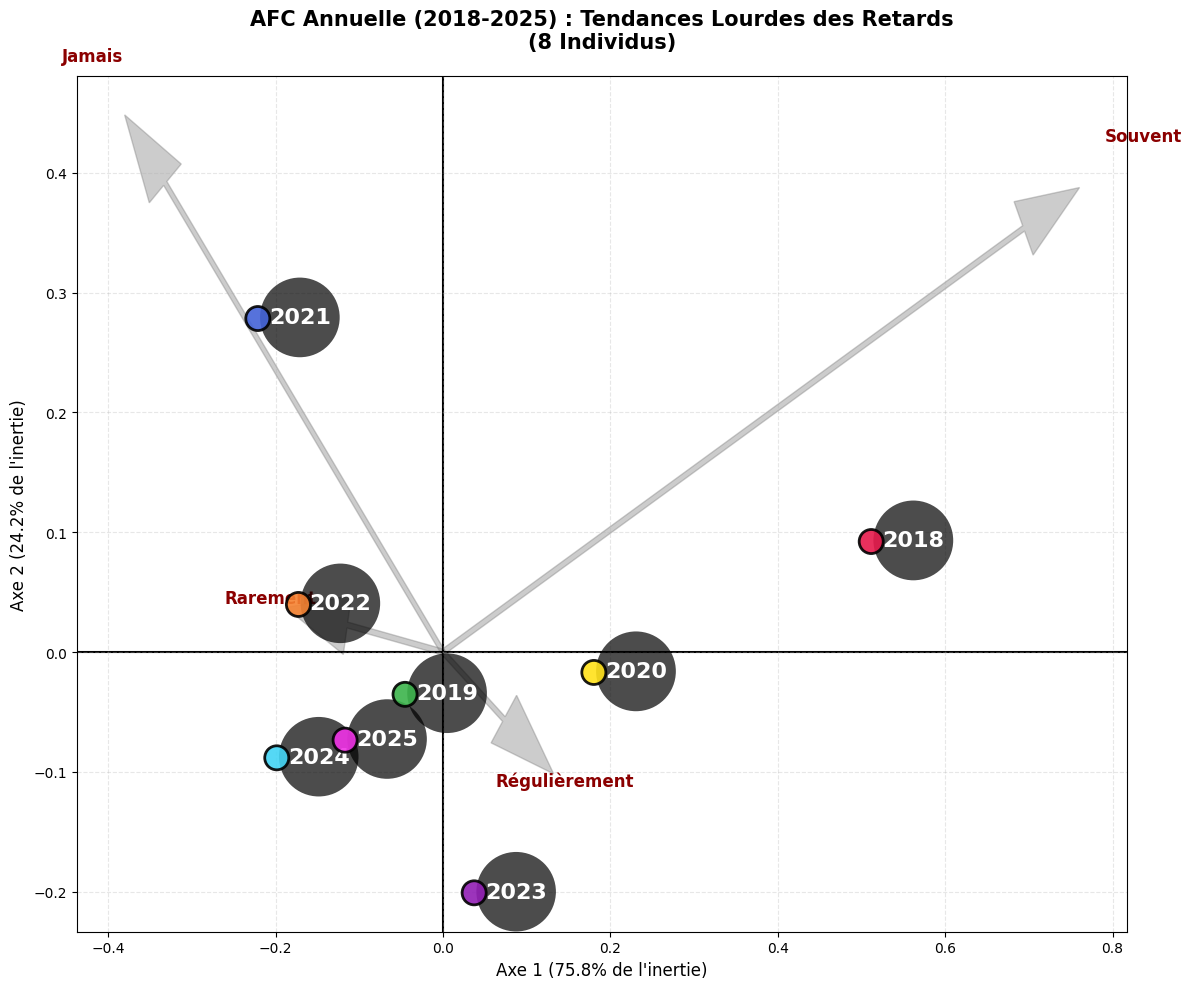

In [12]:
# B.2. AFC spécifique par année (8 individus)

# A. Création de la colonne 'annee' extraite de la date
# On prend les 4 premiers caractères pour être sûr d'avoir l'année.
data['annee_str'] = data['date'].astype(str).str[:4]

# B. Création de la matrice de contingence par ANNÉE
# Groupby (Année, Retard) -> Comptage -> Pivot (unstack)
matrice_annuelle = data.groupby(['annee_str', 'retard']).size().unstack(fill_value=0)

print("\nMatrice de contingence Annuelle (8 individus) :")
print(matrice_annuelle)

# C. Lancement de l'AFC sur les données annuelles
afc_annee = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_annee = afc_annee.fit(matrice_annuelle)

# D. Calcul des inerties pour les titres
total_inertia_annee = afc_annee.eigenvalues_.sum()
inertie_a1 = afc_annee.eigenvalues_[0] / total_inertia_annee
inertie_a2 = afc_annee.eigenvalues_[1] / total_inertia_annee

# E. Visualisation
plt.figure(figsize=(12, 10))

# Récupérer les coordonnées des individus (les années)
coords_annees = afc_annee.row_coordinates(matrice_annuelle)
coords_annees.columns = ['Axe 1', 'Axe 2']

# Récupérer les coordonnées des variables (les catégories de retard) pour les superposer
coords_vars_annee = afc_annee.column_coordinates(matrice_annuelle)
coords_vars_annee.columns = ['Axe 1', 'Axe 2']

# 1. Tracer les flèches des variables (Catégories) en fond
for i, txt in enumerate(coords_vars_annee.index):
    x = coords_vars_annee['Axe 1'].iloc[i]
    y = coords_vars_annee['Axe 2'].iloc[i]
    # Flèche depuis l'origine
    plt.arrow(0, 0, x, y, color='gray', alpha=0.4, width=0.005, head_width=0.05, length_includes_head=True)
    # Nom de la catégorie au bout de la flèche
    plt.text(x*1.1, y*1.1, txt, color='darkred', fontsize=12, fontweight='bold', ha='center')

# 2. Tracer les points des ANNÉES par dessus
# On utilise l'index (qui est l'année) converti en entier pour la couleur
coords_annees['annee_num'] = coords_annees.index.astype(int)

scatter_annee = plt.scatter(
    coords_annees['Axe 1'], 
    coords_annees['Axe 2'], 
    c=coords_annees['annee_num'], 
    cmap=cmap_personnalisee, 
    s=300, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10,
    label='Années'
)

# Ajouter le label de l'année à côté du point
for i, txt in enumerate(coords_annees.index):
    x_val = coords_annees['Axe 1'].iloc[i]
    y_val = coords_annees['Axe 2'].iloc[i]
    # Texte blanc avec contour noir pour lisibilité maximale
    plt.annotate(f"{txt}", (x_val, y_val), 
                 xytext=(8, 8),          # Décalage de 8 points vers le haut-droite
                 textcoords='offset points', # L'unité est en points d'impression (indépendant de l'échelle du graph)
                 ha='left',              # Alignement horizontal à gauche du texte décalé
                 va='top',            # Alignement vertical en bas du texte décalé
                 fontsize=16,            
                 fontweight='bold', 
                 color='white',
                 bbox=dict(boxstyle='circle,pad=0.4', facecolor='black', alpha=0.7, edgecolor='none'))


plt.title("AFC Annuelle (2018-2025) : Tendances Lourdes des Retards\n(8 Individus)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_a1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_a2:.1%} de l'inertie)", fontsize=12)

# Grille et axes
plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **{**AFC_GRID, 'alpha': 0.3})

plt.tight_layout()
plt.show()

On réobserve une répartition des individus sur les deux axes avec une forme de "banane".

On voit que les années 2018 et 2020 sont clairement plus touchées par les retards et qu'il sera intéressant de revoir l'AFC sans les mois "outliers". L'année 2021 est dans la direction de la variable `Jamais`. Elle peut être considérée comme une année performante par rapport aux 8 dernières.

On ne voit pas de tendances globales sur l'ensemble des années qui pourrait nous faire estimer que les retards diminuent ou baissent. On retrouve la vision que les retards moyens semblent se lisser récemment pour stagner entre rarement et régulièrement.

On peut observer cependant que la variance entre les mois se réduit et que les points des années 2023, 2024 et 2025 sont plus concentrés que les années 2018, 2019, 2020 et 2022. L'année 2021 fait figure d'exception de performance et de constance (mise à part le mois de confinement).

On regarde maintenant les effets saisonniers et l'évolution des retards par mois. Nous refaisons une nouvelle AFC sur les données agrégées en mois. Nous cherchons à savoir si il y a des mois plus propices aux retards que d'autres.

### C. AFC saisonnière par mois

Matrice de contingence
retard    Jamais  Rarement  Régulièrement  Souvent
mois_num                                          
01            15       483            477        6
02            50       542            380        9
03            27       487            436       31
04            28       365            322      218
05            33       491            371       81
06            19       384            528       47
07            12       354            578       53
08            50       559            375       12
09            26       589            366       14
10            16       466            487       10
11            17       348            585       33
12            11       393            538       39


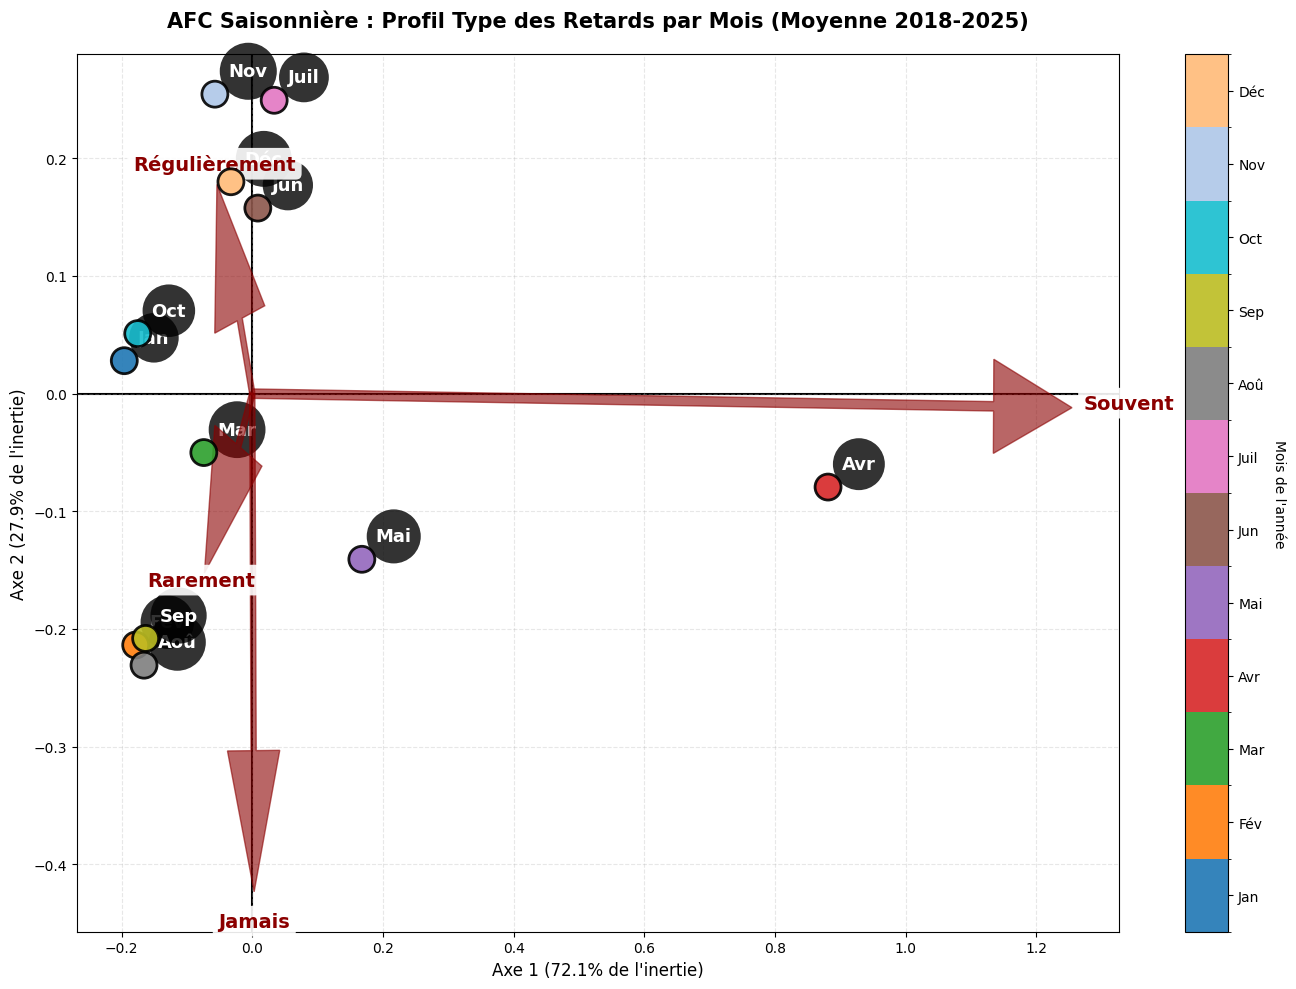

In [13]:
# C. AFC saisonnière globale (12 mois)

# A. Préparation : Extraire le numéro du mois pour le regroupement
data['mois_num'] = data['date'].astype(str).str.split('-').str[1]

# B. Création de la matrice de contingence par MOIS (Agrégation 2018-2025)
matrice_mois = data.groupby(['mois_num', 'retard']).size().unstack(fill_value=0)

# Réordonner les mois chronologiquement (01, 02, ..., 12)
ordre_mois = [f"{i:02d}" for i in range(1, 13)]
mois_presents = [m for m in ordre_mois if m in matrice_mois.index]
matrice_mois = matrice_mois.reindex(mois_presents)

#Afficher la matrice de contigence
print("Matrice de contingence")
print(matrice_mois)

# C. Lancement de l'AFC
afc_mois_global = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_mois_global = afc_mois_global.fit(matrice_mois)

# D. Calcul des inerties
total_inertia_mois = afc_mois_global.eigenvalues_.sum()
inertie_mm1 = afc_mois_global.eigenvalues_[0] / total_inertia_mois
inertie_mm2 = afc_mois_global.eigenvalues_[1] / total_inertia_mois

# E. Préparation des coordonnées
coords_mois_glob = afc_mois_global.row_coordinates(matrice_mois)
coords_mois_glob.columns = ['Axe 1', 'Axe 2']
coords_mois_glob['mois_int'] = coords_mois_glob.index.astype(int)

coords_vars_mois = afc_mois_global.column_coordinates(matrice_mois)
coords_vars_mois.columns = ['Axe 1', 'Axe 2']

# F. Création d'une palette personnalisée de 12 couleurs distinctes
# Liste de 12 couleurs vives et différenciables
couleurs_12_mois = [
    '#1f77b4', # Bleu (Jan)
    '#ff7f0e', # Orange (Fév)
    '#2ca02c', # Vert (Mar)
    '#d62728', # Rouge (Avr)
    '#9467bd', # Violet (Mai)
    '#8c564b', # Marron (Jun)
    '#e377c2', # Rose (Juil)
    '#7f7f7f', # Gris (Aoû)
    '#bcbd22', # Olive (Sep)
    '#17becf', # Cyan (Oct)
    '#aec7e8', # Bleu clair (Nov)
    '#ffbb78'  # Orange clair (Déc)
]

# Création de la colormap et de la normalisation pour des cases discrètes (pour avoir les couleurs centrées sur les mois)
cmap_12 = mcolors.LinearSegmentedColormap.from_list('cmap_12', couleurs_12_mois, N=12)
bornes_mois = [x - 0.5 for x in range(1, 13)] + [12.5] # Bornes de 0.5 à 12.5
norm_mois = mcolors.BoundaryNorm(bornes_mois, cmap_12.N)

# G. Visualisation Unifiée
plt.figure(figsize=FIG_SIZE_MOIS)

# 1. Tracé des VARIABLES (Flèches)
for i, txt in enumerate(coords_vars_mois.index):
    x = coords_vars_mois['Axe 1'].iloc[i]
    y = coords_vars_mois['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, **AFC_ARROW, zorder=5)
    plt.text(x*1.07, y*1.07, txt, **AFC_LABEL,
             bbox={**AFC_LABEL_BBOX, 'alpha': 0.9}, zorder=6)

# 2. Tracé des INDIVIDUS (Les Mois 01-12) avec la nouvelle palette
scatter_mois_glob = plt.scatter(
    coords_mois_glob['Axe 1'], 
    coords_mois_glob['Axe 2'], 
    c=coords_mois_glob['mois_int'], 
    cmap=cmap_12, 
    norm=norm_mois, # Application de la normalisation discrète
    s=350, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=2,
    zorder=10
)

# 3. Annotation des points (Nom du mois)
noms_mois = {
    '01': 'Jan', '02': 'Fév', '03': 'Mar', '04': 'Avr', '05': 'Mai', '06': 'Jun',
    '07': 'Juil', '08': 'Aoû', '09': 'Sep', '10': 'Oct', '11': 'Nov', '12': 'Déc'
}

for i, txt in enumerate(coords_mois_glob.index):
    label = noms_mois.get(txt, txt)
    x_val = coords_mois_glob['Axe 1'].iloc[i]
    y_val = coords_mois_glob['Axe 2'].iloc[i]
    
    plt.annotate(label, (x_val, y_val), 
                 xytext=(10, 10), textcoords='offset points', 
                 ha='left', va='bottom', fontsize=13, fontweight='bold', color='white',
                 bbox=dict(boxstyle='circle,pad=0.5', facecolor='black', alpha=0.8, edgecolor='none'))

# H. Mise en forme et Légende
plt.title("AFC Saisonnière : Profil Type des Retards par Mois (Moyenne 2018-2025)", fontsize=15, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_mm1:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_mm2:.1%} de l'inertie)", fontsize=12)

plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **{**AFC_GRID, 'alpha': 0.3})

# Légende de couleur avec cases discrètes
cbar = plt.colorbar(scatter_mois_glob, ticks=range(1, 13))
cbar.set_label('Mois de l\'année', rotation=270, labelpad=15)
cbar.set_ticklabels(['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Juil', 'Aoû', 'Sep', 'Oct', 'Nov', 'Déc'])

plt.tight_layout()
plt.show()

On voit que Avril reste un outlier car très fortement impacté par les annés 2018, 2020 et 2021 dans nos données.

Le mois de mai a un comportement plutôt étonnant car il comporte beaucoup de `Rarement en retard` et de `Souvent en retard`, ce qui le sort de la forme générale (allant d'en bas à gauche à en haut à droite en passant par en haut à gauche) qui classe globalement les mois par performance de ponctualité.

Août, Septembre et Février présente un profil très similaire et performant. Ces mois répondent à notre question initiale des meilleurs moments pour prendre le train.

Viennent ensuite Janvier, Octobre et Mars avec plus de retard et enfin Juin, Juillet, Novembre et Décembre qui sont très proches de la position de la variable `Régulièrement en retard`.

On peut voir un effet des vacances d'été et de Noël sur les retards avec Juin, Juillet et Décembre dans les mois les moins performants. Août se positionne mieux cependant. Nous avons cherché à savoir si des études avaient trouvé des comportements différenciés entre les vacancier·es du mois de juillet et du mois d'août. Il semblerait qu'il y ait une plus grande part de familles (donc utilisant une voiture) en août qu'en juillet (d'après le travail du sociologue Pierre Perier) mais ces informations ne permettent pas vraiment de tirer de conclusions sur notre cas.

### D. FAMD avec la proportion de retard

Nous allons maintenant utiliser uniquement la variable `Retard` (continue) et l'utiliser pour coupler les deux AFC dans une AFCM. Il s'agit d'un cas très adapté pour cette méthode car nos données sont temporelles et nous voulons à la fois chercher les effets des années et des mois sur les données et le retard.

On repart des données initiales pour créer un data set spécial pour la FAMD.

#### D.1. FAMD globale

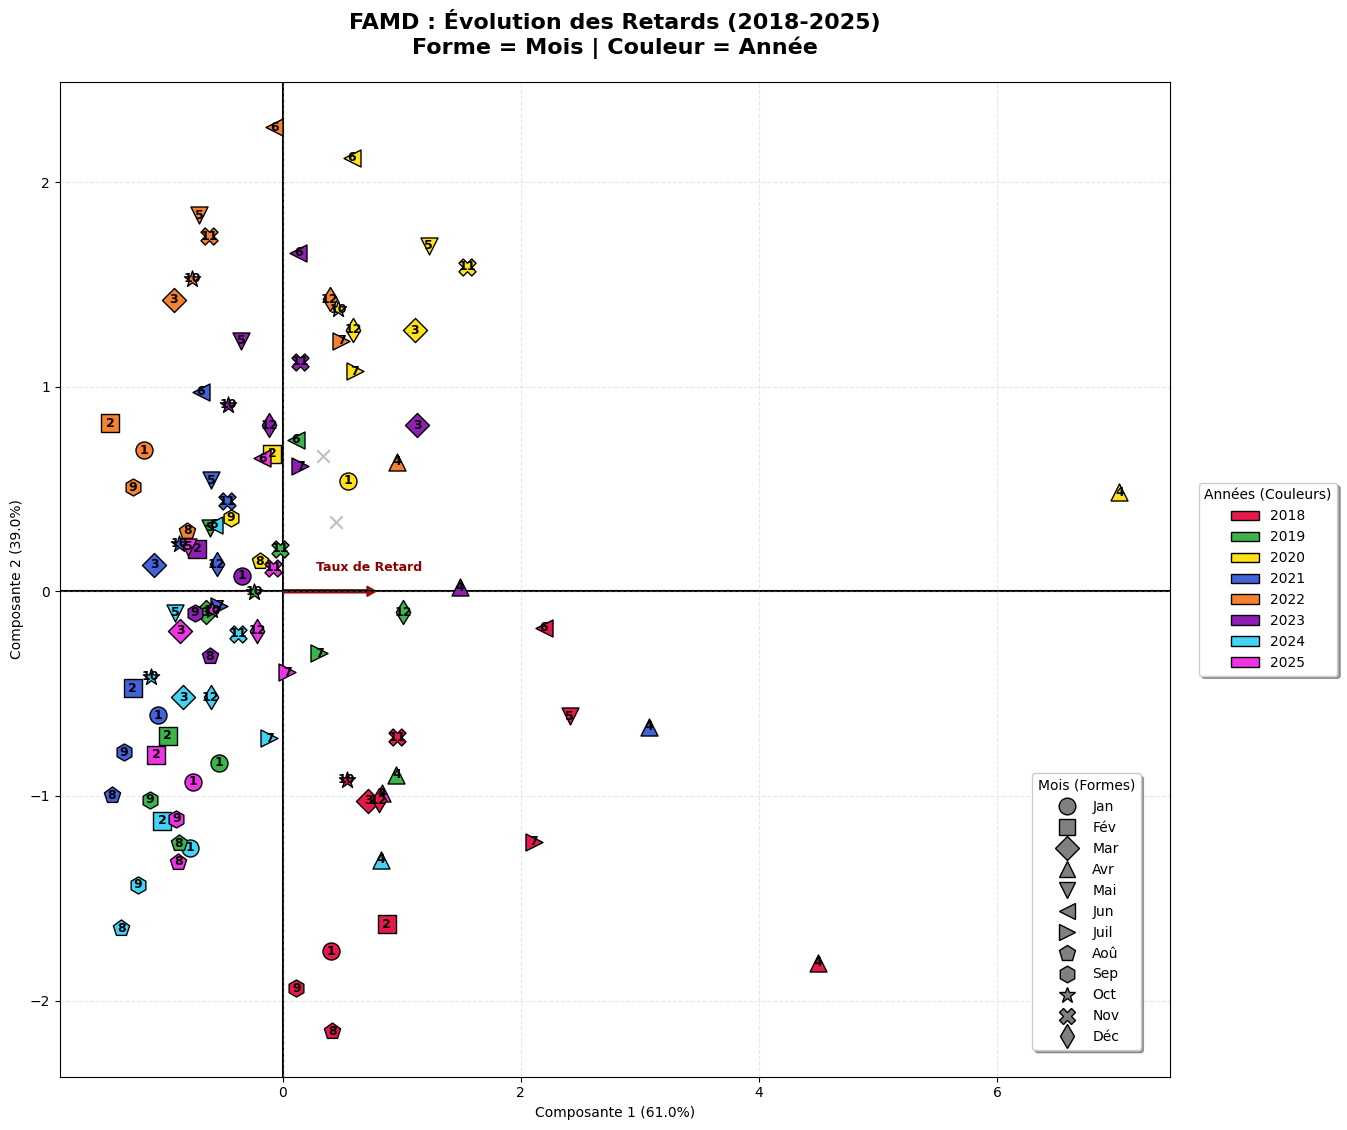

In [14]:
# D.1. FAMD — Variable quantitative continue (Taux de retard)

# A. Préparation des données
df_famd = data.copy()

# Création des variables temporelles
df_famd['date_str'] = df_famd['date'].astype(str)
df_famd['annee_var'] = df_famd['date_str'].str[:4].astype('object')
df_famd['mois_var'] = df_famd['date_str'].str.split('-').str[1].astype('object')
df_famd['individu'] = df_famd['mois_var'] + '-' + df_famd['annee_var']

# Agrégation par individu (Mois-Année)
agg_data = df_famd.groupby(['individu', 'mois_var', 'annee_var']).agg({
    'arr_late_trains': 'sum',
    'cancelled_trains': 'sum',
    'planned_trains': 'sum'
}).reset_index()

# Calcul de la variable quantitative : Proportion de retard (Valeur continue)
agg_data['proportion_retard'] = (
    agg_data['arr_late_trains'] + agg_data['cancelled_trains']
) / agg_data['planned_trains']

# Préparation du dataframe final
df_final = agg_data[['individu', 'mois_var', 'annee_var', 'proportion_retard']].copy()
df_final.set_index('individu', inplace=True)

# B. Lancement de la FAMD
famd = prince.FAMD(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
famd = famd.fit(df_final)

# C. Récupération des coordonnées
coords_ind = famd.row_coordinates(df_final).copy()
coords_ind.columns = ['Axe 1', 'Axe 2']

coords_var = famd.column_coordinates_.copy()
coords_var.columns = ['Axe 1', 'Axe 2']

# Extraction des infos pour le graphique (Correction : ajout de annee_str)
coords_ind['annee_num'] = coords_ind.index.str.split('-').str[1].astype(int)
coords_ind['annee_str'] = coords_ind.index.str.split('-').str[1]  # Colonne manquante ajoutée
coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)

# Séparation des variables pour le tracé
if 'proportion_retard' in coords_var.index:
    var_quant = coords_var.loc[['proportion_retard']]
    var_qual = coords_var.drop('proportion_retard')
else:
    var_quant = coords_var.iloc[[0]]
    var_qual = coords_var.iloc[1:]

# D. Visualisation
plt.figure(figsize=FIG_SIZE_AFC)

# 1. Définition des styles
# Couleurs vives par année
annees_uniques = sorted(coords_ind['annee_str'].unique())
dict_couleurs_annees = {annee: COULEURS_ANNEES[i % len(COULEURS_ANNEES)] for i, annee in enumerate(annees_uniques)}

# Formes par mois
liste_marqueurs_mois = ['o', 's', 'D', '^', 'v', '<', '>', 'p', 'h', '*', 'X', 'd']
mois_uniques = sorted(coords_ind['mois_num'].unique())
dict_marqueurs_mois = {mois: liste_marqueurs_mois[(mois-1) % len(liste_marqueurs_mois)] for mois in mois_uniques}

noms_mois = {1: 'Jan', 2: 'Fév', 3: 'Mar', 4: 'Avr', 5: 'Mai', 6: 'Jun', 
             7: 'Juil', 8: 'Aoû', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Déc'}

# 2. Tracé des variables (Fond)
# Flèche Variable Quantitative
x_q, y_q = var_quant['Axe 1'].iloc[0], var_quant['Axe 2'].iloc[0]
plt.arrow(0, 0, x_q, y_q, color='darkred', alpha=0.9, width=0.015, head_width=0.05, length_includes_head=True, zorder=1)
plt.text(x_q*1.5, 0.1, "Taux de Retard", color='darkred', fontsize=9, fontweight='bold', zorder=2, ha='right')

# Points Variables Qualitatives
for idx, row in var_qual.iterrows():
    x, y = row['Axe 1'], row['Axe 2']
    plt.scatter(x, y, c='gray', s=80, marker='x', alpha=0.5, zorder=1)

# 3. Tracé des individus (Boucle par MOIS)
for mois in mois_uniques:
    df_mois = coords_ind[coords_ind['mois_num'] == mois]
    marker = dict_marqueurs_mois[mois]
    label_mois = noms_mois[mois]
    
    for i, row in df_mois.iterrows():
        annee = row['annee_str']
        couleur = dict_couleurs_annees[annee]
        
        plt.scatter(row['Axe 1'], row['Axe 2'], 
                    c=couleur, 
                    marker=marker, 
                    s=150, 
                    edgecolors='black', 
                    linewidth=1, 
                    alpha=1.0, 
                    zorder=10,
                    label=label_mois if i == df_mois.index[0] else "")
        
# Annotation du numéro du mois à l'intérieur de chaque symbole
    for i, row in df_mois.iterrows():
        plt.text(row['Axe 1'], row['Axe 2'], str(int(row['mois_num'])), 
                 fontsize=9, ha='center', va='center', fontweight='bold', color='black', zorder=11)

# 4. Légendes
# Légende des Mois (Formes)
handles_mois = [plt.Line2D([0], [0], marker=dict_marqueurs_mois[m], color='w', label=noms_mois[m],
                     markerfacecolor='gray', markersize=12, markeredgecolor='black') for m in range(1, 13)]
leg_mois = plt.legend(handles=handles_mois, title="Mois (Formes)", loc='lower right', bbox_to_anchor=(0.98, 0.02), frameon=True, fancybox=True, shadow=True)
plt.gca().add_artist(leg_mois)

# Légende des Années (Couleurs)
handles_annees = [Patch(facecolor=dict_couleurs_annees[a], edgecolor='black', label=a) for a in annees_uniques]
leg_annees = plt.legend(handles=handles_annees, title="Années (Couleurs)", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fancybox=True, shadow=True)

# 5. Titres et Axes
total_inertia = famd.eigenvalues_.sum()
inertie_1 = famd.eigenvalues_[0] / total_inertia
inertie_2 = famd.eigenvalues_[1] / total_inertia

plt.title(f"FAMD : Évolution des Retards (2018-2025)\nForme = Mois | Couleur = Année", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Composante 1 ({inertie_1:.1%})")
plt.ylabel(f"Composante 2 ({inertie_2:.1%})")

plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **{**AFC_GRID, 'alpha': 0.3})

plt.tight_layout(rect=[0, 0.05, 0.85, 1])
plt.show()

Ce premier graphique est plutôt compliqué à interpréter. L'information principale est que la variable Retard est complètement expliqué avec l'axe 1. Cela va nous être très utile pour la suite pour projeter les données sur un espace encore plus petit. Nous ne pouvais pas tirer de conclusion sur le placement des points sur l'axe 2 cependant.

On retrouve sans surprise les mois outliers très à droite. On va garder la FMAD en n'affichant que les mois ou que les années pour faciliter la visualisation et l'interprétation.

#### D.2. Visualisation par mois

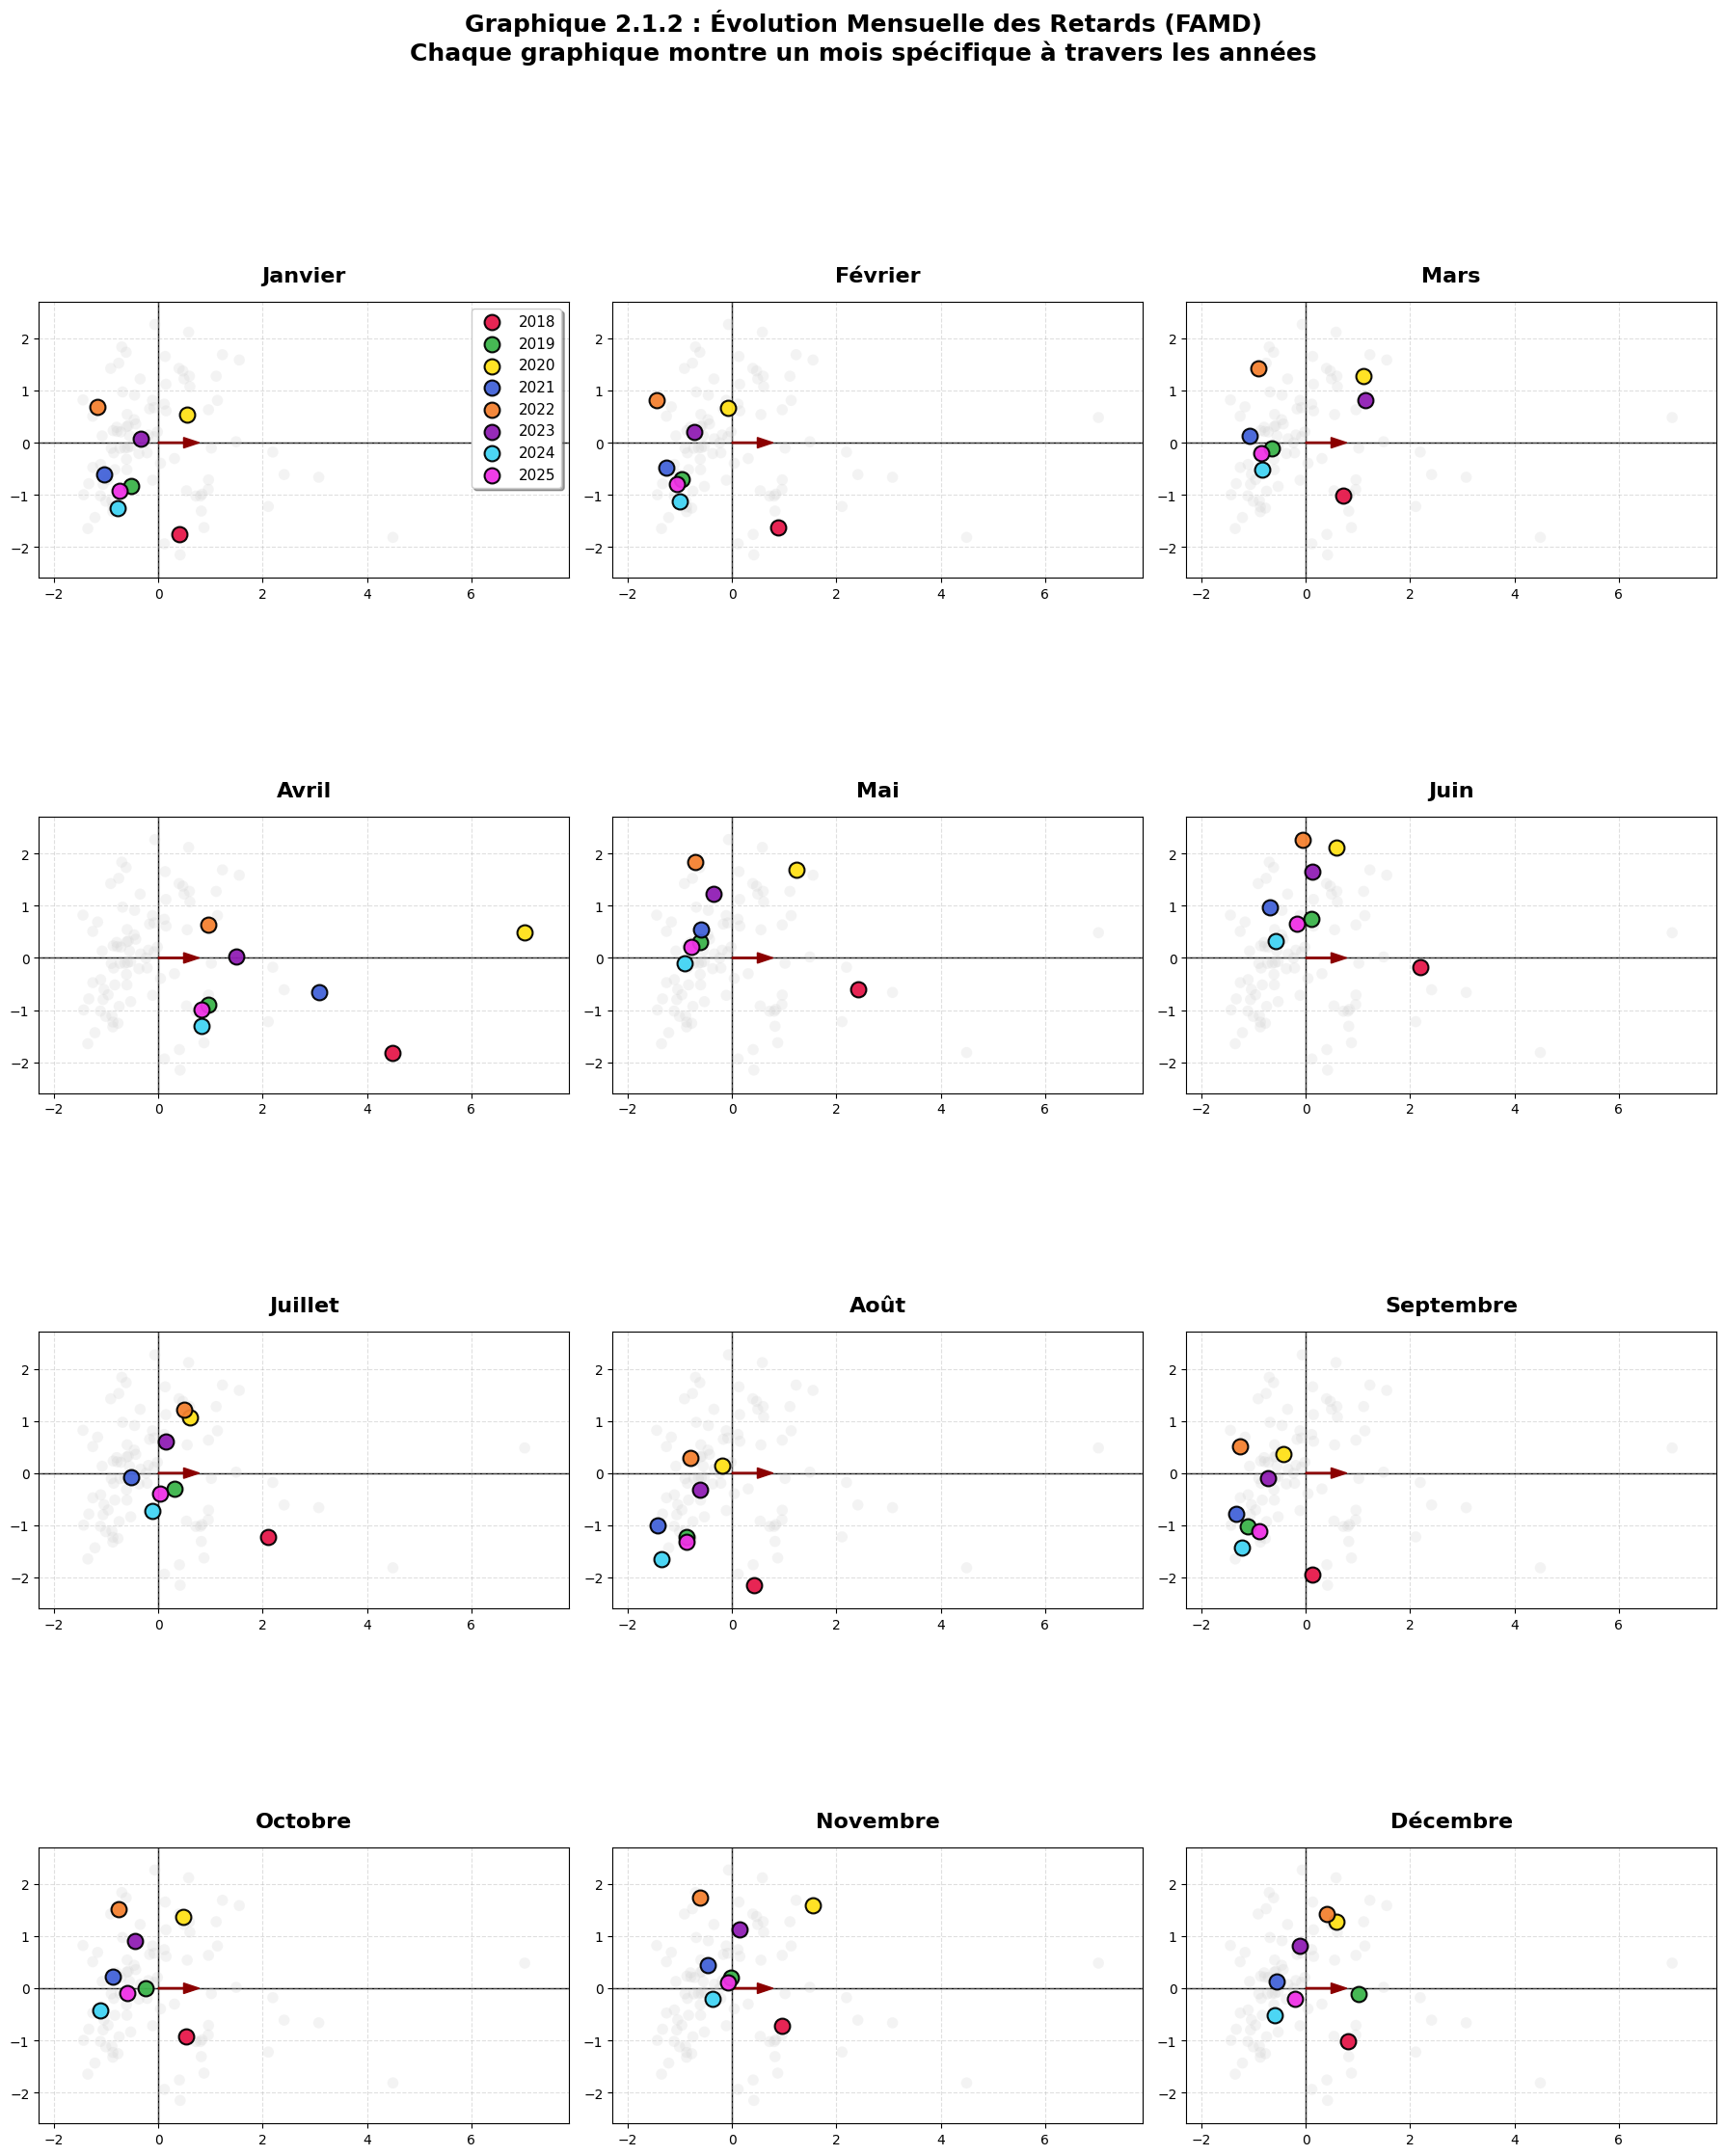

In [15]:
# D.2. Grille comparative FAMD : Un mois par sous-graphique

# A. Préparation des données
if 'annee_str' not in coords_ind.columns:
    coords_ind['annee_str'] = coords_ind.index.str.split('-').str[1]
if 'mois_num' not in coords_ind.columns:
    coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)
if 'annee_num' not in coords_ind.columns:
    coords_ind['annee_num'] = coords_ind['annee_str'].astype(int)

mois_uniques = sorted(coords_ind['mois_num'].unique())
# Noms complets des mois
noms_mois_complets = NOMS_MOIS_COMPLETS

# Configuration de la grille : 4 lignes x 3 colonnes
n_cols = 3
n_rows = 4 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

# Palette de couleurs pour les années
annees_uniques = sorted(coords_ind['annee_str'].unique())
dict_couleurs_annees = {a: COULEURS_ANNEES[i % len(COULEURS_ANNEES)] for i, a in enumerate(annees_uniques)}

# B. Boucle de création des sous-graphiques
for i, mois in enumerate(mois_uniques):
    ax = axes[i]
    nom_mois = noms_mois_complets[mois]
    
    # Filtrage
    df_cible = coords_ind[coords_ind['mois_num'] == mois]
    df_fond = coords_ind[coords_ind['mois_num'] != mois]
    
    # 1. Tracé des variables (Fond)
    # Flèche Quantitative
    if 'proportion_retard' in coords_var.index:
        x_q, y_q = coords_var.loc['proportion_retard', 'Axe 1'], coords_var.loc['proportion_retard', 'Axe 2']
        # Flèche plus épaisse (width=0.025) et plus opaque (alpha=1.0)
        ax.arrow(0, 0, x_q, y_q, color='darkred', alpha=1.0, width=0.025, head_width=0.2, length_includes_head=True, zorder=5)
    
    # 2. Tracé des individus "Fond" (Autres mois)
    if not df_fond.empty:
        ax.scatter(df_fond['Axe 1'], df_fond['Axe 2'], 
                   c='lightgray', s=70, alpha=0.25, edgecolors='none', zorder=3)
    
    # 3. Tracé des individus "Cible" (Mois sélectionné)
    for annee in annees_uniques:
        df_annee = df_cible[df_cible['annee_str'] == annee]
        if not df_annee.empty:
            couleur = dict_couleurs_annees[annee]
            ax.scatter(df_annee['Axe 1'], df_annee['Axe 2'], 
                       c=couleur, s=130, alpha=0.95, edgecolors='black', linewidth=1.5, 
                       label=annee, zorder=10)
                
    # Titre et mise en forme
    ax.set_title(nom_mois, fontsize=16, fontweight='bold', pad=15)
    
    # Limites identiques pour tous les graphiques
    marge_x = (coords_ind['Axe 1'].max() - coords_ind['Axe 1'].min()) * 0.1
    marge_y = (coords_ind['Axe 2'].max() - coords_ind['Axe 2'].min()) * 0.1
    ax.set_xlim(coords_ind['Axe 1'].min() - marge_x, coords_ind['Axe 1'].max() + marge_x)
    ax.set_ylim(coords_ind['Axe 2'].min() - marge_y, coords_ind['Axe 2'].max() + marge_y)
    
    ax.axhline(0, color='black', linewidth=1, zorder=1)
    ax.axvline(0, color='black', linewidth=1, zorder=1)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_aspect('equal')
    
    # Légende uniquement sur le premier graphique (Janvier)
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        # Filtrer pour avoir une légende unique par année
        unique_handles = []
        unique_labels = []
        for h, l in zip(handles, labels):
            if l not in unique_labels:
                unique_labels.append(l)
                unique_handles.append(h)
        ax.legend(unique_handles, unique_labels, loc='upper right', fontsize=11, frameon=True, shadow=True)

# C. Titre global
plt.suptitle("Graphique 2.1.2 : Évolution Mensuelle des Retards (FAMD)\nChaque graphique montre un mois spécifique à travers les années", 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Il semble y avoir de la variance entre les mois. On retrouve une plus grosse propention au retard dans le mois de mars, avril, juillet et décembre.

Le profil déséquilibré du mois de mai se confirme, avec 2 années très peu performantes et 6 plutôt performantes.

On voit encore que les outliers influencent beaucoup le graphique avec l'année 2019 (rouge) qui est placé en bas à droite systématiquement.

On regarde maintenant les années.

#### D.4. Visualisation par année

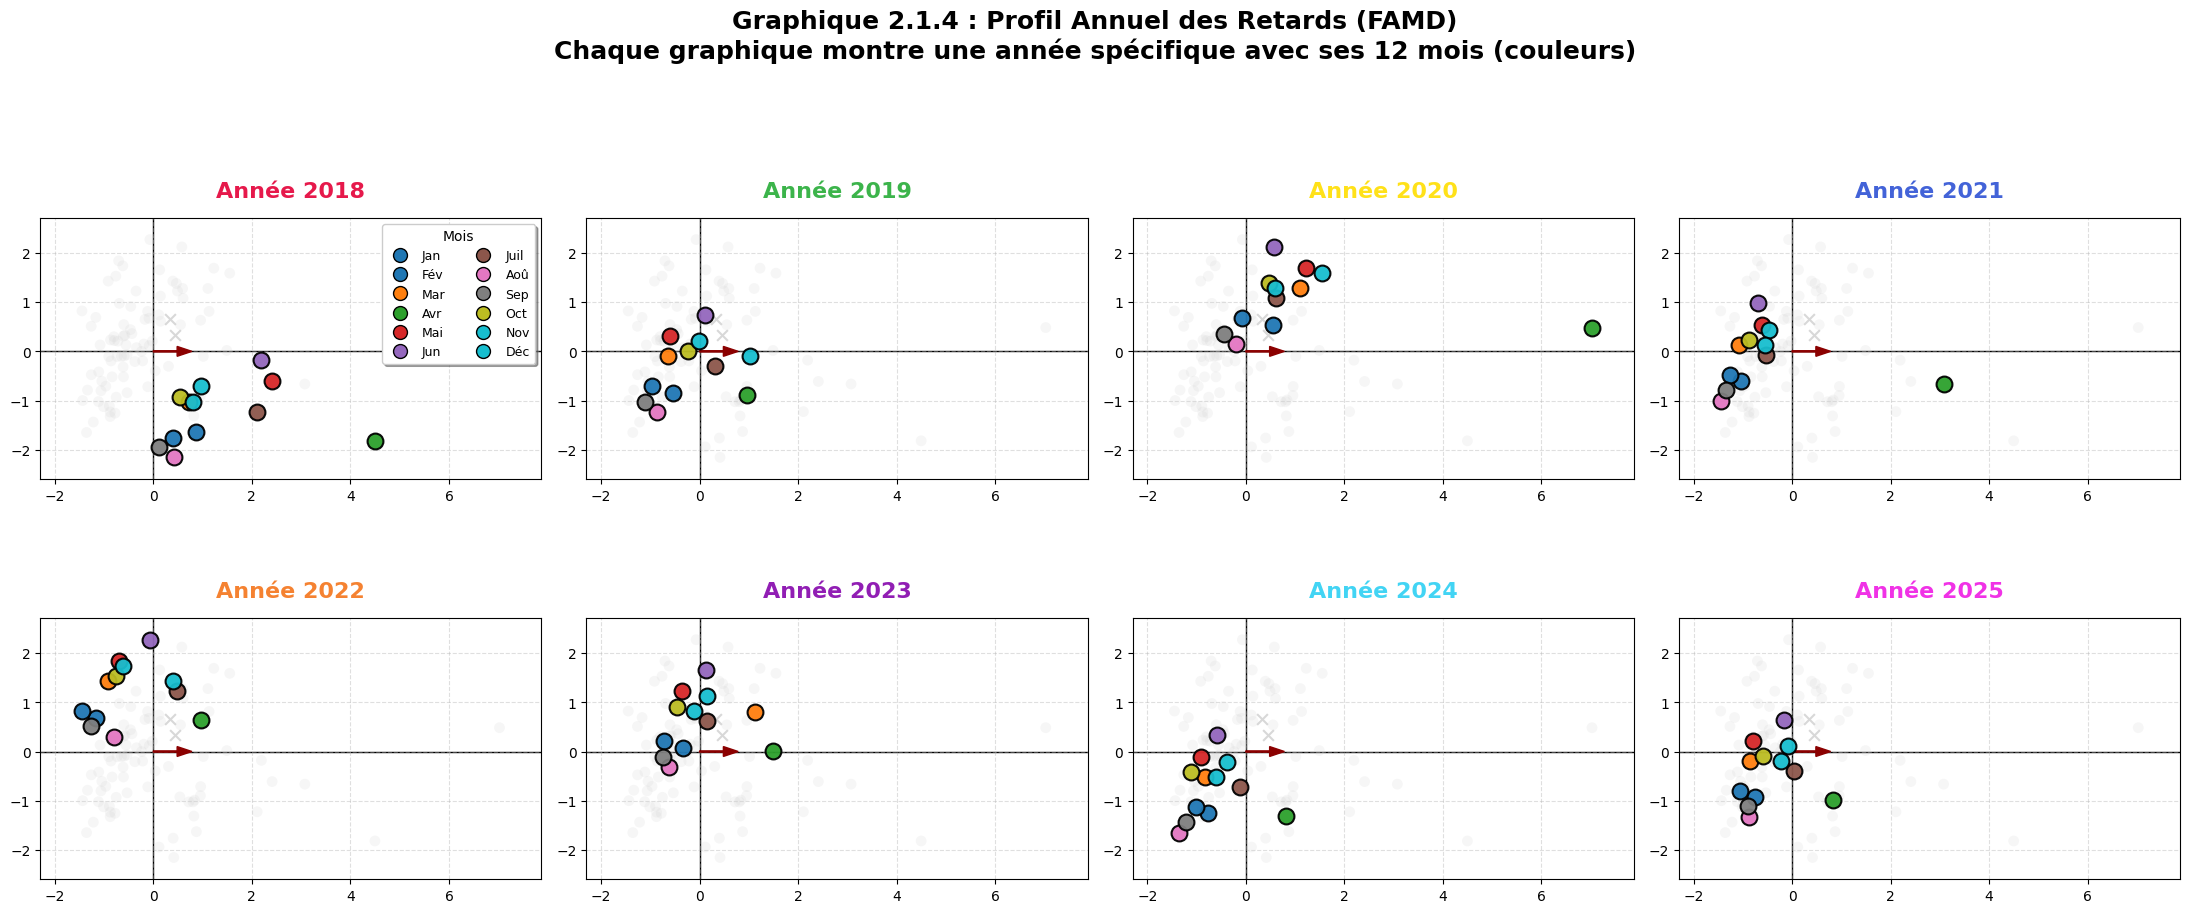

In [16]:
# D.4. Grille comparative FAMD : Une année par sous-graphique

# A. Préparation des données
if 'annee_str' not in coords_ind.columns:
    coords_ind['annee_str'] = coords_ind.index.str.split('-').str[1]
if 'mois_num' not in coords_ind.columns:
    coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)
if 'annee_num' not in coords_ind.columns:
    coords_ind['annee_num'] = coords_ind['annee_str'].astype(int)

annees_uniques = sorted(coords_ind['annee_str'].unique())
n_annees = len(annees_uniques)
noms_mois = NOMS_MOIS

# Configuration de la grille : 2 lignes x 4 colonnes
n_cols = 4
n_rows = 2 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 5 * n_rows))
axes = axes.flatten()

# Palette de couleurs vives (identique aux précédents)
dict_couleurs_annees = {a: COULEURS_ANNEES[i % len(COULEURS_ANNEES)] for i, a in enumerate(annees_uniques)}

# B. Boucle de création des sous-graphiques
for i, annee in enumerate(annees_uniques):
    ax = axes[i]
    couleur_cible = dict_couleurs_annees[annee]
    
    # Filtrage des données
    df_cible = coords_ind[coords_ind['annee_str'] == annee]
    df_fond = coords_ind[coords_ind['annee_str'] != annee]
    
    # 1. Tracé des variables (Fond)
    # Flèche Quantitative (Renforcée)
    if 'proportion_retard' in coords_var.index:
        x_q, y_q = coords_var.loc['proportion_retard', 'Axe 1'], coords_var.loc['proportion_retard', 'Axe 2']
        ax.arrow(0, 0, x_q, y_q, color='darkred', alpha=1.0, width=0.025, head_width=0.2, length_includes_head=True, zorder=5)
        
    # Points Qualitatifs (Gris)
    for idx, row in coords_var.iterrows():
        if idx == 'proportion_retard': continue
        ax.scatter(row['Axe 1'], row['Axe 2'], c='gray', s=60, marker='x', alpha=0.3, zorder=2)
    
    # 2. Tracé des individus "Fond" (Autres années, grisés)
    if not df_fond.empty:
        ax.scatter(df_fond['Axe 1'], df_fond['Axe 2'], 
                   c='lightgray', s=60, alpha=0.2, edgecolors='none', zorder=3)
    
    # 3. Tracé des individus "Cible" (L'année sélectionnée, colorée par MOIS)
    # On utilise une palette pour les mois afin de distinguer Jan, Fév, etc. dans la même année
    # On réutilise la palette 'tab10' ou une liste personnalisée pour les 12 mois
    couleurs_mois = plt.get_cmap('tab10')(np.linspace(0, 1, 12))
    # Ou une liste manuelle si préférée, ici on utilise tab10 pour la simplicité dans la boucle
    
    for j, row in df_cible.iterrows():
        mois = row['mois_num']
        # Couleur basée sur le mois (index 0 à 11)
        couleur_point = couleurs_mois[(mois-1) % 12]
        
        ax.scatter(row['Axe 1'], row['Axe 2'], 
                   c=[couleur_point], s=130, alpha=0.95, edgecolors='black', linewidth=1.5, 
                   label=noms_mois[mois], zorder=10)
    
    # Titre et mise en forme
    ax.set_title(f"Année {annee}", fontsize=16, fontweight='bold', color=couleur_cible, pad=15)
    
    # Limites identiques pour tous
    marge_x = (coords_ind['Axe 1'].max() - coords_ind['Axe 1'].min()) * 0.1
    marge_y = (coords_ind['Axe 2'].max() - coords_ind['Axe 2'].min()) * 0.1
    ax.set_xlim(coords_ind['Axe 1'].min() - marge_x, coords_ind['Axe 1'].max() + marge_x)
    ax.set_ylim(coords_ind['Axe 2'].min() - marge_y, coords_ind['Axe 2'].max() + marge_y)
    
    ax.axhline(0, color='black', linewidth=1, zorder=1)
    ax.axvline(0, color='black', linewidth=1, zorder=1)
    ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
    ax.set_aspect('equal')
    
    # Légende des mois uniquement sur le premier graphique
    if i == 0:
        handles = []
        labels = []
        for m in range(1, 13):
            c = couleurs_mois[(m-1) % 12]
            handles.append(plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=c, markersize=10, markeredgecolor='black'))
            labels.append(noms_mois[m])
        ax.legend(handles, labels, loc='upper right', title="Mois", ncol=2, fontsize=9, frameon=True, shadow=True)

# C. Titre global
plt.suptitle("Graphique 2.1.4 : Profil Annuel des Retards (FAMD)\nChaque graphique montre une année spécifique avec ses 12 mois (couleurs)", 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Il est étonnant de remarquer que la plupart des années ont leur points plutôt concentrés dans une zone du graphique. Il semblerait que l'axe 2 porte une signification (très visible pour 2021, 2020, 2024 et 2025) mais nous n'avons réussi à imaginer ce que cela pouvait être dans cette réduction de dimension en particulier.

On observe la très bonne performance de 2021 et le regroupement progressif dans les années 2024 et 2025 sur des années plutôt performantes et constantes.

2022 et 2023 ont des profils similaires. On retrouve leur individus projetés dans un espace similaire, comme dans l'AFC par années de la partie précédente.

On va maintenant utiliser la possibilité de projeter les données sur l'axe 1 pour réduire encore la dimension et observer les évolutions de la performance de chaque mois au cours du temps en ordonnant par année.

#### D.3. Évolution de la composante 1 par mois

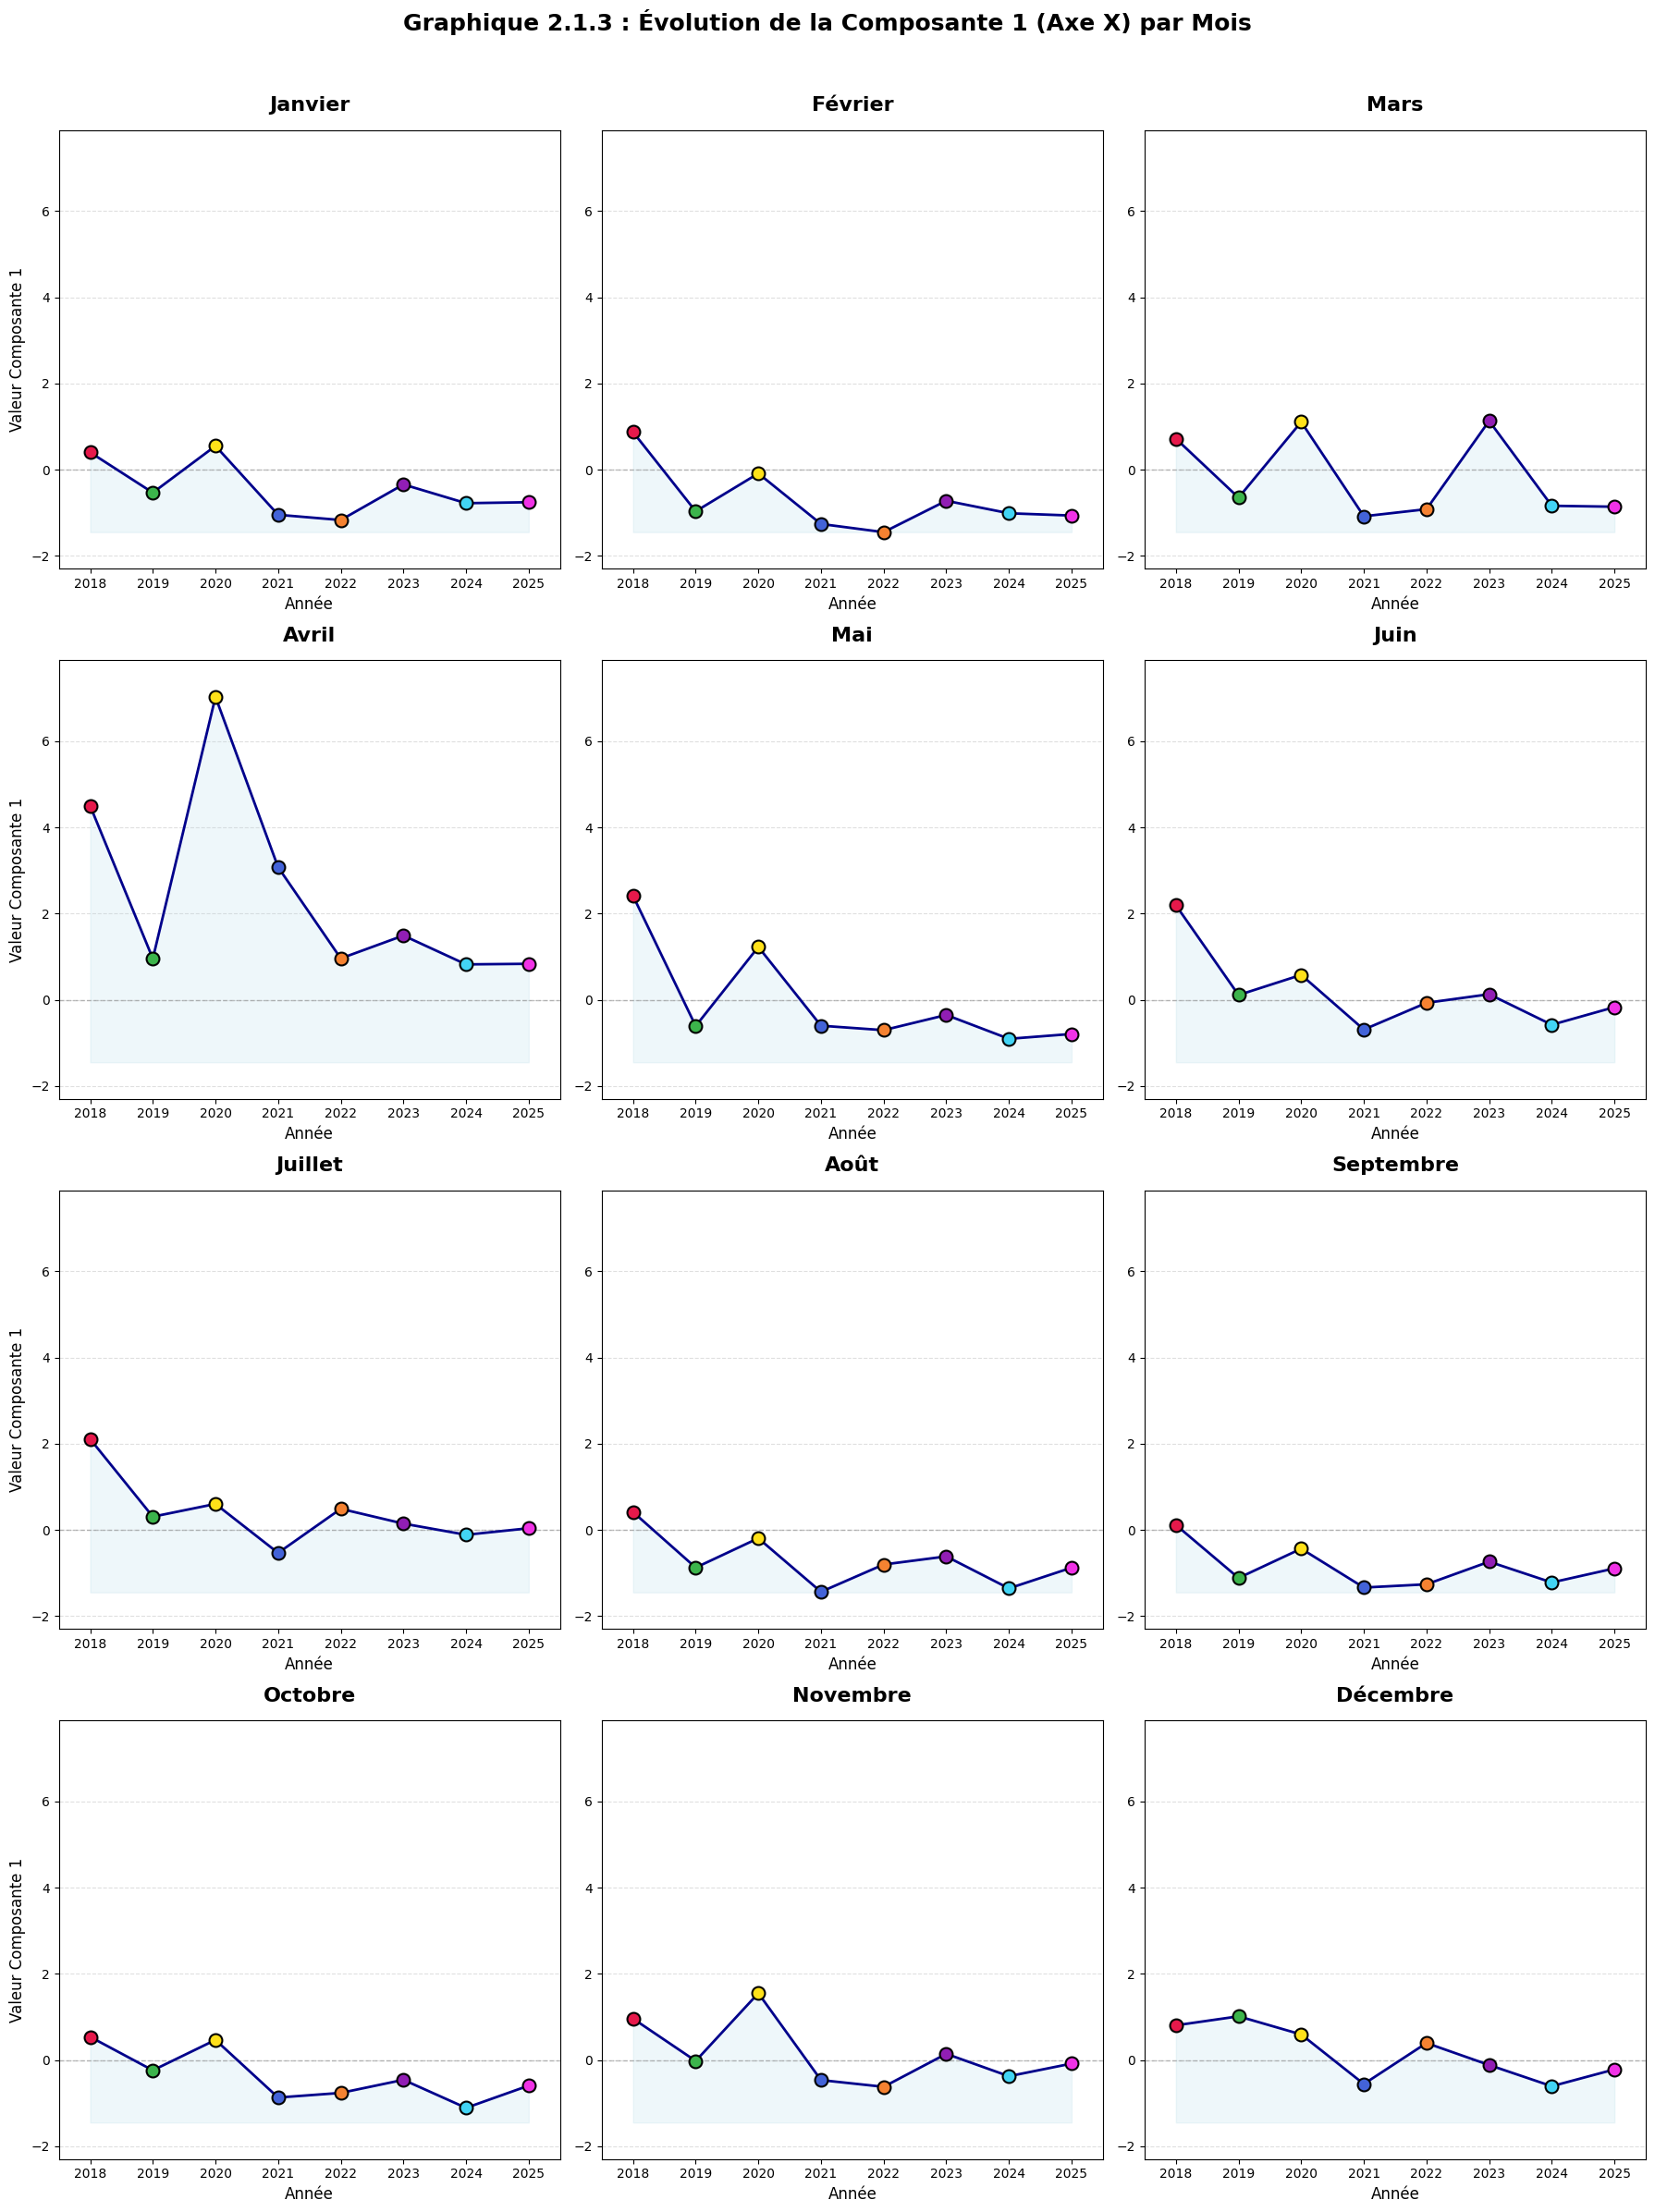

In [17]:
# D.3. Évolution temporelle de la Composante 1 par mois

# A. Préparation des données
if 'annee_num' not in coords_ind.columns:
    coords_ind['annee_num'] = coords_ind.index.str.split('-').str[1].astype(int)
if 'mois_num' not in coords_ind.columns:
    coords_ind['mois_num'] = coords_ind.index.str.split('-').str[0].astype(int)

mois_uniques = sorted(coords_ind['mois_num'].unique())
noms_mois_complets = NOMS_MOIS_COMPLETS

# Configuration de la grille : 4 lignes x 3 colonnes
n_cols = 3
n_rows = 4 

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6 * n_rows))
axes = axes.flatten()

# Palette de couleurs pour les années (pour cohérence avec les graphiques précédents)
annees_uniques = sorted(coords_ind['annee_num'].unique())
dict_couleurs_annees = {a: COULEURS_ANNEES[i % len(COULEURS_ANNEES)] for i, a in enumerate(annees_uniques)}

# Récupération des limites globales de l'Axe Y (Composante 1) pour uniformiser les graphiques
y_min_global = coords_ind['Axe 1'].min()
y_max_global = coords_ind['Axe 1'].max()
marge_y = (y_max_global - y_min_global) * 0.1

# B. Boucle de création des sous-graphiques
for i, mois in enumerate(mois_uniques):
    ax = axes[i]
    nom_mois = noms_mois_complets[mois]
    
    # Filtrage des données pour ce mois
    df_mois = coords_ind[coords_ind['mois_num'] == mois].sort_values('annee_num')
    
    if df_mois.empty:
        ax.text(0.5, 0.5, "Données manquantes", ha='center', va='center', transform=ax.transAxes)
        ax.set_title(nom_mois, fontsize=14, fontweight='bold')
        continue

    # Extraction des séries temporelles
    x_annees = df_mois['annee_num']
    y_composante1 = df_mois['Axe 1']
    
    # Tracé de la ligne d'évolution
    ax.plot(x_annees, y_composante1, color='darkblue', linewidth=2, linestyle='-', marker='o', markersize=8, zorder=10)
    
    # Remplissage sous la courbe (Optionnel, pour la lisibilité)
    ax.fill_between(x_annees, y_composante1, y_min_global, color='lightblue', alpha=0.2, zorder=1)
    
    # Coloration des points par année (pour garder le code couleur)
    for idx, row in df_mois.iterrows():
        annee = row['annee_num']
        couleur = dict_couleurs_annees[annee]
        ax.scatter(row['annee_num'], row['Axe 1'], c=couleur, s=100, edgecolors='black', linewidth=1.5, zorder=11)

    # Mise en forme
    ax.set_title(nom_mois, fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Année", fontsize=12)
    if i % 3 == 0: # Axe Y label uniquement sur la colonne de gauche
        ax.set_ylabel("Valeur Composante 1", fontsize=12)
    
    # Limites uniformes
    ax.set_xlim(2017.5, 2025.5) # Marge autour des années
    ax.set_ylim(y_min_global - marge_y, y_max_global + marge_y)
    
    # Ligne de référence à 0
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    
    ax.grid(True, linestyle='--', alpha=0.4, axis='y')
    ax.set_axisbelow(True)

# C. Titre global
plt.suptitle("Graphique 2.1.3 : Évolution de la Composante 1 (Axe X) par Mois", 
             fontsize=18, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

Dans ces graphiques, nous avons simplement projeté la valeur sur la première composante pour chaque mois de chaque année (rangé par mois ici) en ordonnant les valeurs pour observer l'évolution.

On peut ainsi mieux observer les comportements de chaque mois :
- le mois de mai apparait finalement plus stable que dans les autres graphiques (en fait les 2 années particuliers sont celles des grèves et du covid) et il est plutôt performant au final
- Octobre et Septembre confirme des performances constantes
- le mois de décembre est le seul à avoir eu des moins bonnes performances en 2019 qu'en 2018 et également le seul à avoir eu des meilleurs performances en 2020 qu'en 2019
- Mars, Avril et Juin marquent une plus grande inconstance
- on répère de nouveau la baisse de la variance des retards au cours du temps

### E. Analyses sans les outliers

Enfin, on s'intéresse aux mêmes réductions de dimensions mais en ignorant les mois spécifiques des grèves de 2018 et des confinement à savoir :
- Mars, Avril, Mai et Juin 2018
- Mars, Avril, Mai 2020 / Novembre, Decembre 2020 / Avril 2021

On commence par nettoyer les données de ces valeurs et de les préparer pour refaire 2 AFC.

In [18]:
# E.0. Préparation des données : Exclusion des périodes outliers

# Liste des périodes à exclure (Mois, Année)
# Mars, Avril, Mai, Juin 2018
# Mars, Avril, Mai, Nov, Dec 2020 + Avril 2021
periodes_a_exclure = [
    (3, 2018), (4, 2018), (5, 2018), (6, 2018),
    (3, 2020), (4, 2020), (5, 2020), (11, 2020), (12, 2020),
    (4, 2021)
]

# Création d'une copie propre des données
data_clean = data.copy()
data_clean['mois_num'] = data_clean['date'].astype(str).str.split('-').str[1].astype(int)
data_clean['annee_num'] = data_clean['date'].astype(str).str.split('-').str[1].astype(int) # Correction: str[:4]
data_clean['annee_num'] = data_clean['date'].astype(str).str[:4].astype(int)

# Création d'un tuple (mois, annee) pour chaque ligne
data_clean['tuple_date'] = list(zip(data_clean['mois_num'], data_clean['annee_num']))

# Filtrage : On garde uniquement les lignes qui NE SONT PAS dans la liste d'exclusion
mask_clean = ~data_clean['tuple_date'].isin(periodes_a_exclure)
data_clean = data_clean[mask_clean].copy()

# Nettoyage des colonnes temporaires
data_clean.drop(columns=['mois_num', 'annee_num', 'tuple_date'], inplace=True)

print(f"Nombre de lignes avant filtrage : {len(data)}")
print(f"Nombre de lignes après filtrage : {len(data_clean)}")
print(f"Périodes exclues : {len(periodes_a_exclure)} mois spécifiques.")

Nombre de lignes avant filtrage : 11834
Nombre de lignes après filtrage : 10581
Périodes exclues : 10 mois spécifiques.


#### E.1. AFC globale hors outliers

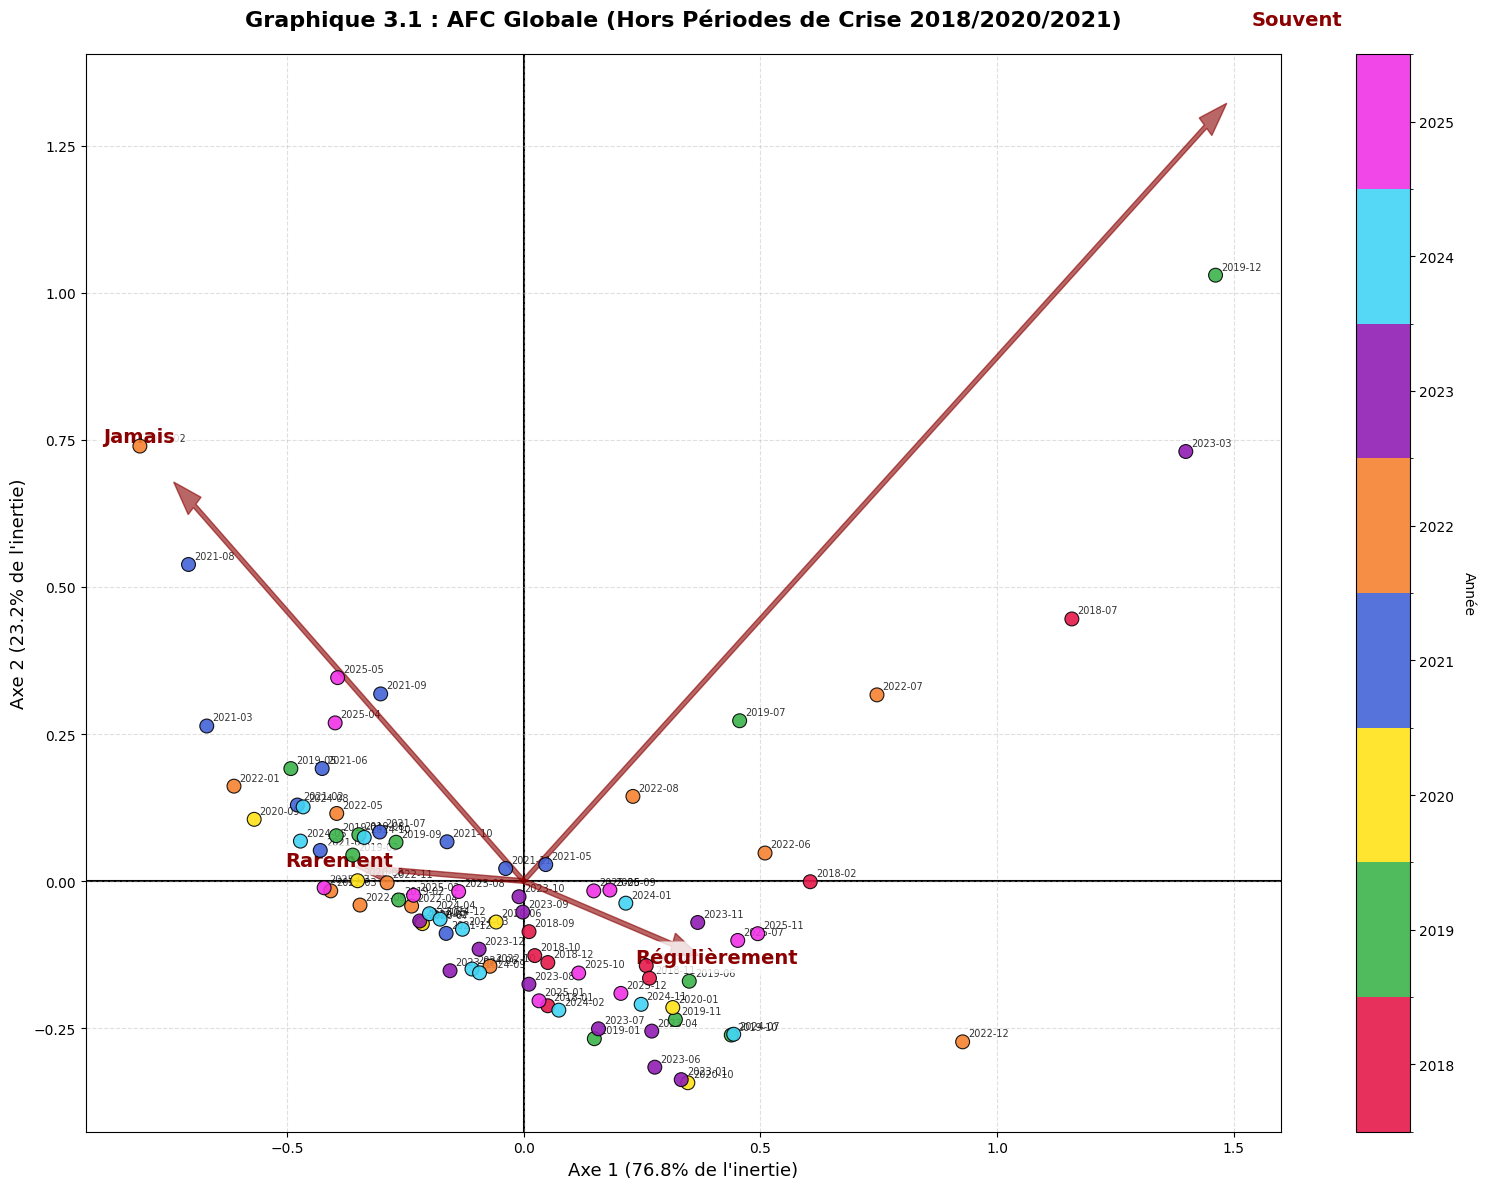

Inertie Axe 1: 76.8% | Axe 2: 23.2%


In [19]:
# E.1. AFC globale (hors outliers)

# A. Préparation de la matrice de contingence sur les données nettoyées
data_clean['periode'] = data_clean['date'].astype(str)
matrice_clean = data_clean.groupby(['periode', 'retard']).size().unstack(fill_value=0)

# B. Lancement de l'AFC
afc_clean = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_clean = afc_clean.fit(matrice_clean)

# C. Récupération des coordonnées
coords_ind_clean = afc_clean.row_coordinates(matrice_clean)
coords_ind_clean.columns = ['Axe 1', 'Axe 2']
coords_var_clean = afc_clean.column_coordinates(matrice_clean)
coords_var_clean.columns = ['Axe 1', 'Axe 2']

# Extraction et CONVERSION FORCÉE en entier
coords_ind_clean['annee_str'] = coords_ind_clean.index.str[:4]
coords_ind_clean['annee_num'] = coords_ind_clean['annee_str'].astype(int) # Force le type int

# Calcul des inerties
total_inertia_clean = afc_clean.eigenvalues_.sum()
inertie_1_clean = afc_clean.eigenvalues_[0] / total_inertia_clean
inertie_2_clean = afc_clean.eigenvalues_[1] / total_inertia_clean

# D. Visualisation
plt.figure(figsize=FIG_SIZE_AFC)

# 1. Tracé des variables (Flèches)
for i, txt in enumerate(coords_var_clean.index):
    x, y = coords_var_clean['Axe 1'].iloc[i], coords_var_clean['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, **{**AFC_ARROW, 'head_width': 0.04}, zorder=5)
    plt.text(x*1.1, y*1.1, txt, **AFC_LABEL, bbox=AFC_LABEL_BBOX, zorder=6)

# 2. Définition de la palette et des bornes
annees_uniques_clean = sorted(coords_ind_clean['annee_num'].unique()) # Liste d'entiers

# Création de la colormap
cmap_clean = mcolors.LinearSegmentedColormap.from_list('cmap_8', COULEURS_ANNEES[:len(annees_uniques_clean)], N=len(annees_uniques_clean))

# Création des bornes : on s'assure qu'elles sont bien FLOAT pour BoundaryNorm
# Bornes : [2017.5, 2018.5, 2019.5, ..., 2025.5]
bornes = [float(x) - 0.5 for x in range(int(annees_uniques_clean[0]), int(annees_uniques_clean[-1]) + 2)]
norm_clean = mcolors.BoundaryNorm(bornes, cmap_clean.N)

# 3. Tracé des individus
# On utilise explicitement la colonne 'annee_num' (qui est int)
scatter_clean = plt.scatter(
    coords_ind_clean['Axe 1'], 
    coords_ind_clean['Axe 2'], 
    c=coords_ind_clean['annee_num'], 
    cmap=cmap_clean, 
    norm=norm_clean,
    s=100, 
    alpha=0.9, 
    edgecolors='black', 
    linewidth=0.8,
    zorder=10
)

# Annotation des points
for i, txt in enumerate(coords_ind_clean.index):
    x_val = coords_ind_clean['Axe 1'].iloc[i]
    y_val = coords_ind_clean['Axe 2'].iloc[i]
    plt.annotate(txt, (x_val, y_val), xytext=(4, 4), textcoords='offset points', fontsize=7, alpha=0.8)

# Légende de couleur
cbar = plt.colorbar(scatter_clean, ticks=annees_uniques_clean)
cbar.set_label('Année', rotation=270, labelpad=15)
cbar.set_ticklabels([str(int(a)) for a in annees_uniques_clean])

plt.title("Graphique 3.1 : AFC Globale (Hors Périodes de Crise 2018/2020/2021)", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_1_clean:.1%} de l'inertie)", fontsize=13)
plt.ylabel(f"Axe 2 ({inertie_2_clean:.1%} de l'inertie)", fontsize=13)

plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **AFC_GRID)

plt.tight_layout()
plt.show()

print(f"Inertie Axe 1: {inertie_1_clean:.1%} | Axe 2: {inertie_2_clean:.1%}")

Dans ce nouveau graphique, on observe une répartition globale des données similaires au graphique avec les outliers. On voit que les points sont toutefois plus étalés et que la variable `Régulièrement en retard` à glisser plus vers la droite. Les variables sont projetées de façon très similaires sur le graphique.

Un point étonnant est que maintenant la valeur "extrême" est Décembre 2019. Après des recherches, il s'agit d'un autre épisode de grève à la SNCF : https://www.leparisien.fr/economie/direct-la-greve-dans-les-transports-perturbe-le-week-end-de-depart-en-vacances-de-noel-21-12-2019-8222406.php. Le mouvement social était moins important qu'en 2018 mais maintenant on peut voir l'effet significatif.

Pour Mars 2023, on retrouve également un épisode de contestations de la réforme des retraites : https://www.ladepeche.fr/2023/03/22/greve-du-23-mars-un-tgv-sur-deux-un-ter-sur-trois-le-trafic-sncf-sera-tres-fortement-perturbe-ce-jeudi-11080548.php. Il semblerait que d'après les médias la majorité des retards et annulations aient eu lieu sur quelques journées seulement mais qui ont suffit pour influencer fortement les moyennes de retard sur le mois entier. Pour rappel 2023 n'est pas une année très performante dans l'ensemble.

Pour Juillet 2018, il semblerait que cela soit du à la fin des grèves du printemps accompagnés de grands départs en vacances.

On s'intéresse maintenant au graphiques de l'AFC par année.

#### E.2. AFC annuelle hors outliers

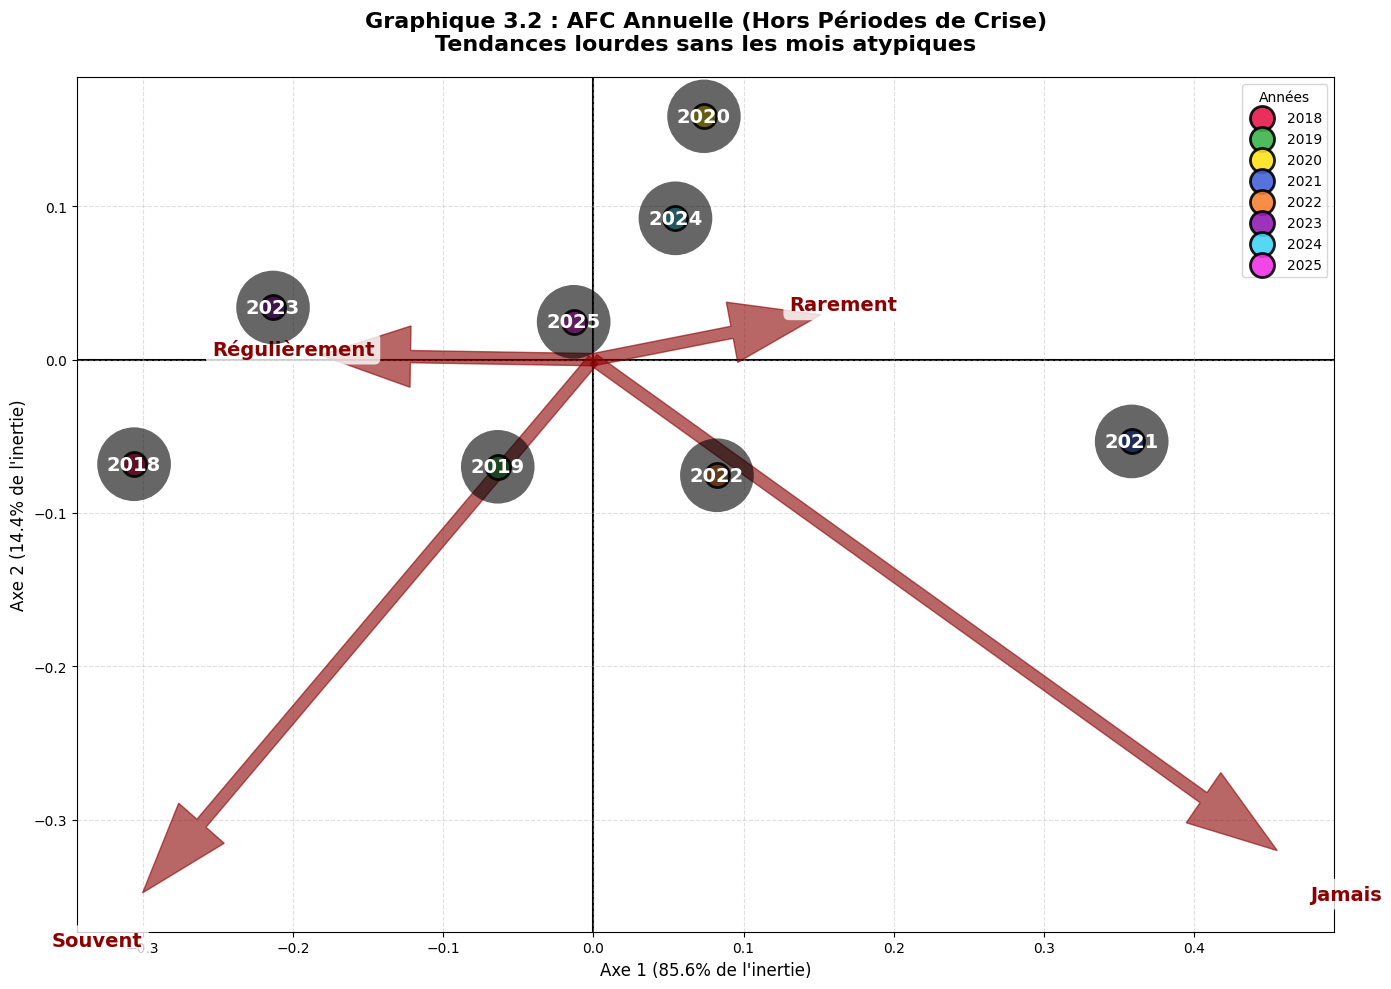

Inertie Axe 1: 85.6% | Axe 2: 14.4%
Analyse : La trajectoire entre les années est-elle plus linéaire que dans le graphique 1.2 ?


In [20]:
# E.2. AFC annuelle agrégée (hors outliers)

# A. Agrégation par année sur les données nettoyées
data_clean['annee_str'] = data_clean['date'].astype(str).str[:4]
# On regroupe par Année et Retard
matrice_annuelle_clean = data_clean.groupby(['annee_str', 'retard']).size().unstack(fill_value=0)

# Réordonnancement chronologique
matrice_annuelle_clean = matrice_annuelle_clean.reindex(sorted(matrice_annuelle_clean.index))

# B. Lancement de l'AFC
afc_annuel_clean = prince.CA(n_components=2, n_iter=10, copy=True, check_input=True, random_state=42)
afc_annuel_clean = afc_annuel_clean.fit(matrice_annuelle_clean)

# C. Récupération des coordonnées
coords_annuel_clean = afc_annuel_clean.row_coordinates(matrice_annuelle_clean)
coords_annuel_clean.columns = ['Axe 1', 'Axe 2']
coords_var_annuel_clean = afc_annuel_clean.column_coordinates(matrice_annuelle_clean)
coords_var_annuel_clean.columns = ['Axe 1', 'Axe 2']

# Calcul des inerties
total_inertia_annuel_clean = afc_annuel_clean.eigenvalues_.sum()
inertie_a1_clean = afc_annuel_clean.eigenvalues_[0] / total_inertia_annuel_clean
inertie_a2_clean = afc_annuel_clean.eigenvalues_[1] / total_inertia_annuel_clean

# D. Visualisation
plt.figure(figsize=FIG_SIZE_MOIS)

# 1. Tracé des variables (Flèches)
for i, txt in enumerate(coords_var_annuel_clean.index):
    x, y = coords_var_annuel_clean['Axe 1'].iloc[i], coords_var_annuel_clean['Axe 2'].iloc[i]
    plt.arrow(0, 0, x, y, **{**AFC_ARROW, 'head_width': 0.04}, zorder=5)
    plt.text(x*1.1, y*1.1, txt, **AFC_LABEL, bbox=AFC_LABEL_BBOX, zorder=6)

# 2. Tracé des individus (Années)
# Palette discrète pour les années restantes
annees_presentes = sorted(coords_annuel_clean.index.astype(int))
couleurs_map = {str(a): COULEURS_ANNEES[i % len(COULEURS_ANNEES)] for i, a in enumerate(annees_presentes)}

for i, annee in enumerate(coords_annuel_clean.index):
    x, y = coords_annuel_clean.loc[annee, 'Axe 1'], coords_annuel_clean.loc[annee, 'Axe 2']
    couleur = couleurs_map.get(annee, 'gray')
    
    plt.scatter(x, y, c=couleur, s=300, alpha=0.9, edgecolors='black', linewidth=2, zorder=10, label=annee)
    plt.text(x, y, str(annee), ha='center', va='center', fontsize=14, fontweight='bold', color='white',
             bbox=dict(boxstyle='circle,pad=0.5', facecolor='black', alpha=0.6, edgecolor='none'), zorder=11)

plt.title("Graphique 3.2 : AFC Annuelle (Hors Périodes de Crise)\nTendances lourdes sans les mois atypiques", fontsize=16, fontweight='bold', pad=20)
plt.xlabel(f"Axe 1 ({inertie_a1_clean:.1%} de l'inertie)", fontsize=12)
plt.ylabel(f"Axe 2 ({inertie_a2_clean:.1%} de l'inertie)", fontsize=12)

plt.axhline(0, **AFC_HLINE)
plt.axvline(0, **AFC_HLINE)
plt.grid(True, **AFC_GRID)
plt.legend(loc='best', title="Années")

plt.tight_layout()
plt.show()

print(f"Inertie Axe 1: {inertie_a1_clean:.1%} | Axe 2: {inertie_a2_clean:.1%}")
print("Analyse : La trajectoire entre les années est-elle plus linéaire que dans le graphique 1.2 ?")

Pour ce graphique, on perd complètement l'organisation précédente des variables dans le plan. Le sens de lecture pour l'augmentation des retards est inversé (de en bas à droite à en bas à gauche en passant par le haut) et les années sont plus uniformément réparties maintenant.

Les variables Rarement et Régulièrement sont cependant mal représentées dans l'AFC. On perd donc plus d'informations dans la réduction de dimension et on apprend que les valeurs outlier influençaient fortement la projection des variables.

2018 et 2019 restent des années moins performantes, 2021 a un profil moins ultra performant dans cette nouvelle projection.

En conclusion de cette partie, on peut dire que les mouvements sociaux et les périodes de confinements sont les évènements qui ont les effets les plus marquants sur les retards et non pas les effets saisonniers ou l'évolution au cours des années.

Cependant, on peut dégager des tendances saisonnières avec la meilleure performance de certains mois et de certaines années. La tendance actuelle est à la stabilisation des retards dans un intervalle un peu performant. L'année 2021 est un exemple de performance (une des pistes d'explication est que 2021 est une année où l'État s'est engagé dans la relance économique et dans de nombreux chantiers pour les infrastrures de transport notamment).

On peut dire que la SNCF améliore ses performances globalement au cours du temps et qu'elle lisse les écarts saisonniers.